In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import corner
import seaborn as sns
import matplotlib.lines as mlines
current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
from class_analysis import metrics_creator
from class_analysis import plot_roman_rubin_plt
from class_analysis import create_df_to_plot
from class_analysis import graph_maker_1plot
from tqdm.notebook import tqdm
from read_save import read_data
from ssh_connect import ssh_che
from connect_CHE import download_data
from matplotlib.colors import LogNorm
%matplotlib inline

Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin/notebooks


ModuleNotFoundError: No module named 'class_analysis'

# Load files and compute metrics

In [6]:
import pyarrow.dataset as ds

model = 'FSPL'
# path= parent_directory+f'/all_results/{"FFP"}/'
# fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
# fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
# true = pd.read_parquet(path+"/true.parquet")

dataset_true = ds.dataset(parent_directory+"/all_results/data_PB/true_ds/", format="parquet", partitioning="hive")
dataset_fit_rr = ds.dataset(parent_directory+"/all_results/data_PB/fit_rr_ds/", format="parquet", partitioning="hive")
dataset_fit_roman = ds.dataset(parent_directory+"/all_results/data_PB/fit_roman_ds/", format="parquet", partitioning="hive")

true = dataset_true.to_table().to_pandas()
fit_rr = dataset_fit_rr.to_table().to_pandas()
fit_roman =  dataset_fit_roman.to_table().to_pandas()
true

,Source,Set,t_center,u_center,tE,rho,separation,mass_ratio,alpha,piEN,...,r_rpeak,i_rpeak,z_rpeak,y_rpeak,anomaly_u,u,u_peak,u_npeak,u_lpeak,u_rpeak
0,0,1,2.462005e+06,-0.000046,242.320411,0.000101,0.804940,1.041922e-04,4.058272,0.001827,...,2.0,7.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2.461296e+06,-0.000167,167.652629,0.000079,0.633880,6.362663e-08,0.580181,0.004010,...,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,1,2.462601e+06,-0.000003,35.372279,0.000281,4.138425,2.574796e-03,1.412439,0.032238,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,1,2.462881e+06,-0.000692,54.347867,0.000233,1.921736,1.845323e-04,0.763841,-0.003897,...,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000,1,2.461822e+06,0.000194,161.783107,0.000087,1.364842,9.521399e-04,1.334126,0.008817,...,25.0,49.0,31.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15029,993,4,2.460804e+06,-0.000103,759.472814,0.000109,0.479631,3.253400e-04,2.633878,-0.014873,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15030,994,4,2.462920e+06,0.000031,293.417113,0.000017,0.328728,5.384932e-05,4.564627,-0.012841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15031,996,4,2.461196e+06,-0.000122,307.065122,0.000117,0.361002,3.577042e-04,2.675036,-0.000255,...,NaN,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15032,998,4,2.461033e+06,0.000020,1708.634546,0.000017,0.877049,7.206602e-05,5.125981,-0.020932,...,0.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# plt.hist(true["tE"],np.logspace(-1,4,30))
# plt.xscale("log")
# plt.axvline(2*np.pi,color='red')

In [7]:
# path = parent_directory+'/all_results/USBL_last/'
# fit_rr = pd.read_parquet(path+"/fit_rr.parquet")
# fit_roman =  pd.read_parquet(path+"/fit_roman.parquet")
# path_pspl = parent_directory+'/all_results/PSPL_dfit_Planet_systems/'
# fit_rr_pspl = pd.read_parquet(path_pspl+"/fit_rr.parquet")
# fit_roman_pspl =  pd.read_parquet(path_pspl+"/fit_roman.parquet")
# true = pd.read_parquet(path+"/true.parquet")

roman_detected = true['W149_peak'] != 0
rubin_detected = (
    (true['u_peak'] != 0) |
    (true['g_peak'] != 0) |
    (true['r_peak'] != 0) |
    (true['i_peak'] != 0) |
    (true['z_peak'] != 0) |
    (true['y_peak'] != 0)
)

# Define categories using boolean masks
cat_A_mask = roman_detected & rubin_detected
cat_B_mask = ~roman_detected & rubin_detected
cat_C_mask = roman_detected & ~rubin_detected
cat_D_mask = ~roman_detected & ~rubin_detected

# Assign flags
conditions = [cat_A_mask, cat_B_mask, cat_C_mask, cat_D_mask]
choices = ['A', 'B', 'C', 'D']
true['peak_flag'] = np.select(conditions, choices, default=None)

In [5]:
true

,Source,Set,t_center,u_center,tE,rho,separation,mass_ratio,alpha,piEN,...,r_rpeak,i_rpeak,z_rpeak,y_rpeak,anomaly_u,u,u_peak,u_npeak,u_lpeak,u_rpeak
0,0,1,2.462005e+06,-0.000046,242.320411,0.000101,0.804940,1.041922e-04,4.058272,0.001827,...,2.0,7.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2.461296e+06,-0.000167,167.652629,0.000079,0.633880,6.362663e-08,0.580181,0.004010,...,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,1,2.462601e+06,-0.000003,35.372279,0.000281,4.138425,2.574796e-03,1.412439,0.032238,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,1,2.462881e+06,-0.000692,54.347867,0.000233,1.921736,1.845323e-04,0.763841,-0.003897,...,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000,1,2.461822e+06,0.000194,161.783107,0.000087,1.364842,9.521399e-04,1.334126,0.008817,...,25.0,49.0,31.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15029,993,4,2.460804e+06,-0.000103,759.472814,0.000109,0.479631,3.253400e-04,2.633878,-0.014873,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15030,994,4,2.462920e+06,0.000031,293.417113,0.000017,0.328728,5.384932e-05,4.564627,-0.012841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15031,996,4,2.461196e+06,-0.000122,307.065122,0.000117,0.361002,3.577042e-04,2.675036,-0.000255,...,NaN,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15032,998,4,2.461033e+06,0.000020,1708.634546,0.000017,0.877049,7.206602e-05,5.125981,-0.020932,...,0.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Explore the parameter space simulated

## Here we show the impact parameter $|u_c|$ from the CROIN parametrization as function of the separation between the two lenses



In [8]:

from pyLIMA.caustics import binary_caustics
class originclass:
    def __init__(self, pyLIMA_parameters, origin):
        self.pyLIMA_parameters = pyLIMA_parameters
        self.origin = origin

        
    def new_origin(self, pyLIMA_parameters=None):
        """
    
        """
    
        if 'caustic' in self.origin[0]:
    
            caustic_regime = binary_caustics.find_2_lenses_caustic_regime(
                pyLIMA_parameters['separation'],
                pyLIMA_parameters['mass_ratio'])
    
            caustics = binary_caustics.caustic_points_at_phi_0(
                pyLIMA_parameters['separation'],
                pyLIMA_parameters['mass_ratio'])
    
            caustic = 0 + 0 * 1j
    
            if caustic_regime == 'resonant':
                caustic = caustics[caustics.real.argmin()]
    
            if (caustic_regime == 'wide') & (self.origin[0] == 'central_caustic'):
                caustic = caustics[caustics.real.argmin()]
    
            if (caustic_regime == 'wide') & ((self.origin[0] != 'central_caustic')):
                sorting = caustics.real.argsort()
                caustic = caustics[sorting[2]]
    
            if (caustic_regime == 'close') & (self.origin[0] == 'central_caustic'):
                sorting = caustics.imag.argsort()
                caustic = caustics[
                    np.where(caustics.real == caustics[sorting[1:3]].real.min())[0]]
    
            if (caustic_regime == 'close') & (self.origin[0] == 'second_caustic'):
                caustic = caustics[caustics.imag.argmax()]
    
            if (caustic_regime == 'close') & (self.origin[0] == 'third_caustic'):
                caustic = caustics[caustics.imag.argmin()]
    
            x_center = caustic.real
            y_center = caustic.imag
            return x_center, y_center
    
        if 'primary' in self.origin[0]:
            primary_location = -pyLIMA_parameters['separation'] * \
                               pyLIMA_parameters['mass_ratio'] / (
                                       1 + pyLIMA_parameters['mass_ratio'])
    
            x_center = primary_location
            y_center = 0
            return x_center, y_center
    
        if 'secondary' in self.origin[0]:
            secondary_location = pyLIMA_parameters['separation'] / (
                    1 + pyLIMA_parameters['mass_ratio'])
    
            x_center = secondary_location
            y_center = 0
            return x_center, y_center
    
        if 'half' in self.origin[0]:
            x_center = pyLIMA_parameters['separation'] / 2
            y_center = 0
            return x_center, y_center
    
        x_center = self.origin[1][0]
        y_center = self.origin[1][1]
    
        return x_center, y_center



In [9]:
# params

In [10]:
# find_2_lenses_caustic_regime(true['separation'].iloc[0],true['mass_ratio'].iloc[0])


In [11]:
# true

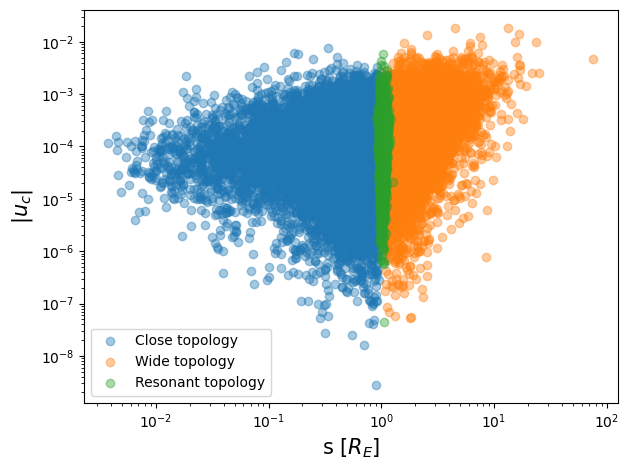

In [12]:
s = true['separation']
q = true['mass_ratio']
uc = true['u_center']
# 
ct_mask = q/(1+q)**2<(((1-s**4)/3)**3)*(s**(-8))
s_ct = s[ct_mask]
uc_ct = uc[ct_mask]

wt_mask = s>np.sqrt(((1+q**(1/3))**3)/(1+q))
s_wt = s[wt_mask]
uc_wt = uc[wt_mask]
rt_mask =(~ct_mask)&(~wt_mask)
# Assign flags based on masks
conditions = [ct_mask, wt_mask, rt_mask]
choices = ['ct', 'wt', 'rt']
true['topology'] = np.select(conditions, choices, default=None)

plt.close('all')
plt.figure(dpi=100)
# plt.scatter(true['separation'],abs(true['u_center']), alpha=0.3)
plt.scatter(s_ct,abs(uc_ct),alpha=0.4,label='Close topology')
plt.scatter(s_wt,abs(uc_wt),alpha=0.4,label='Wide topology')
plt.scatter(s[rt_mask],abs(uc[rt_mask]),alpha = 0.4, label='Resonant topology')

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r's [$R_E$]',fontsize=15)
plt.ylabel(r'$|u_c|$',fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

## Here we observe the parallax $|\pi_E|$ as function of the Einstein time $t_E$


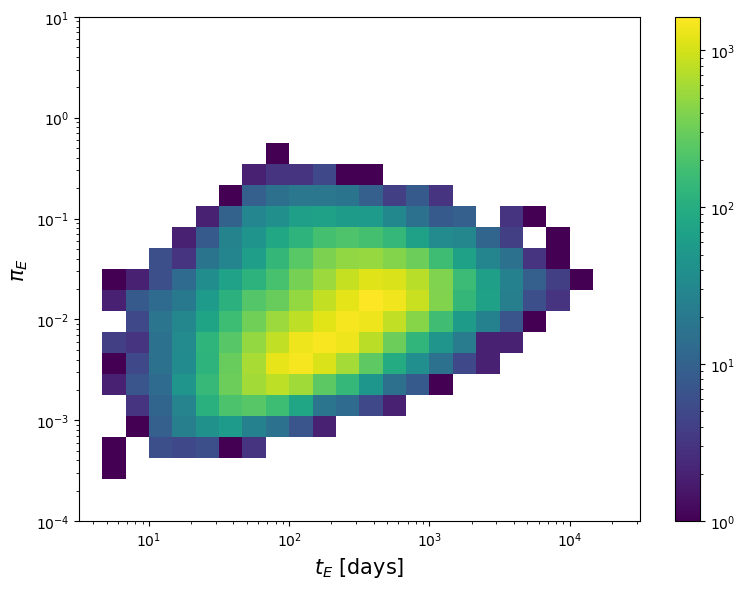

In [13]:
from matplotlib.colors import LogNorm
plt.close('all')
plt.figure(figsize=(8,6),dpi=100)
h = plt.hist2d(true['tE'],true['piE'],bins=(np.logspace(0.5,4.5,25),np.logspace(-4,1,25)), norm=LogNorm())
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\pi_E$',fontsize=15)
plt.xlabel(r'$t_E$ [days]',fontsize=15)
plt.colorbar(h[3])
plt.tight_layout()
plt.show()

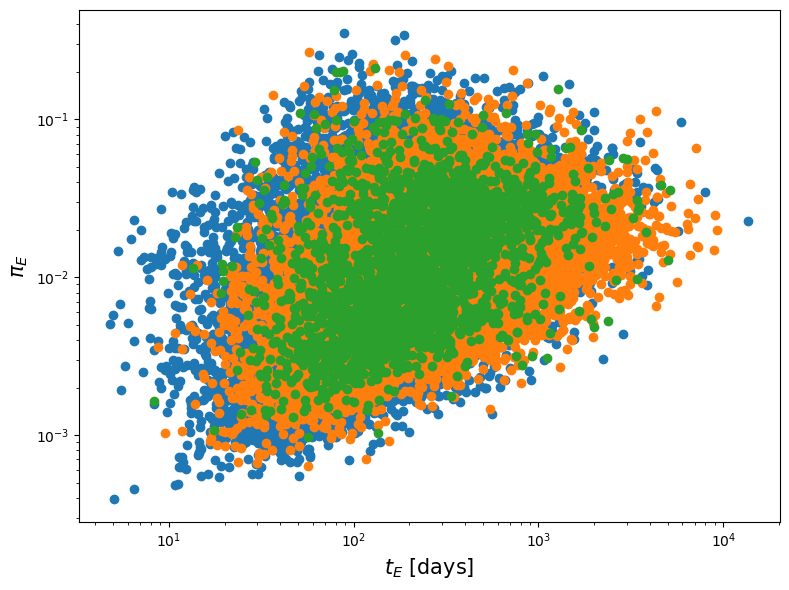

In [14]:
from matplotlib.colors import LogNorm
plt.close('all')
plt.figure(figsize=(8,6),dpi=100)
tE = true['tE']
piE = true['piE']

plt.scatter(tE[wt_mask],piE[wt_mask])
plt.scatter(tE[ct_mask],piE[ct_mask])
plt.scatter(tE[rt_mask],piE[rt_mask])
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\pi_E$',fontsize=15)
plt.xlabel(r'$t_E$ [days]',fontsize=15)
# plt.colorbar(h[3])
plt.tight_layout()
plt.show()

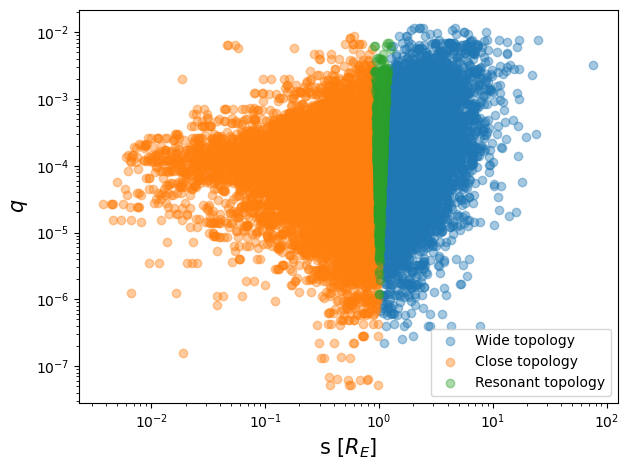

In [15]:
plt.close('all')
plt.figure(dpi=100)

plt.scatter(s[wt_mask],q[wt_mask],alpha=0.4,label='Wide topology')
plt.scatter(s[ct_mask],q[ct_mask],alpha=0.4,label='Close topology')
plt.scatter(s[rt_mask],q[rt_mask],alpha = 0.4, label='Resonant topology')

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r's [$R_E$]',fontsize=15)
plt.ylabel(r'$q$',fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

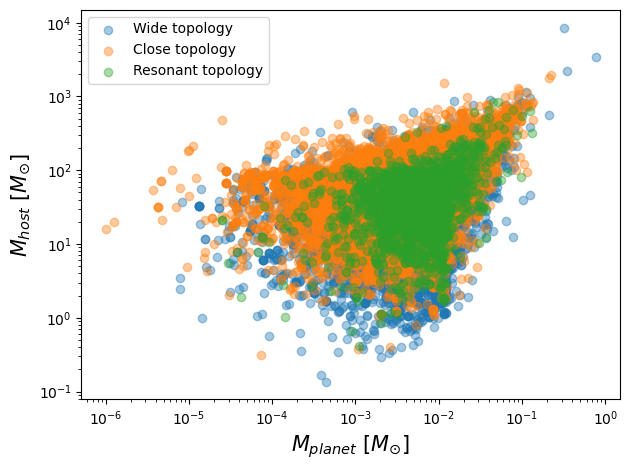

In [16]:
plt.close('all')
plt.figure(dpi=100)

Mp =true['mass']*true['mass_ratio']/(true['mass_ratio']+1)
Mh =Mp/true['mass_ratio']


# plt.scatter(Mp,Mh)

plt.scatter(Mp[wt_mask],Mh[wt_mask],alpha=0.4,label='Wide topology')
plt.scatter(Mp[ct_mask],Mh[ct_mask],alpha=0.4,label='Close topology')
plt.scatter(Mp[rt_mask],Mh[rt_mask],alpha = 0.4, label='Resonant topology')

plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$M_{planet}$ [$M_{\odot}$]',fontsize=15)
plt.ylabel(r'$M_{host}$ [$M_{\odot}$]',fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()

# What is the fraction of events with small chi2


In [17]:
# fit_rr.columns#['chi2']

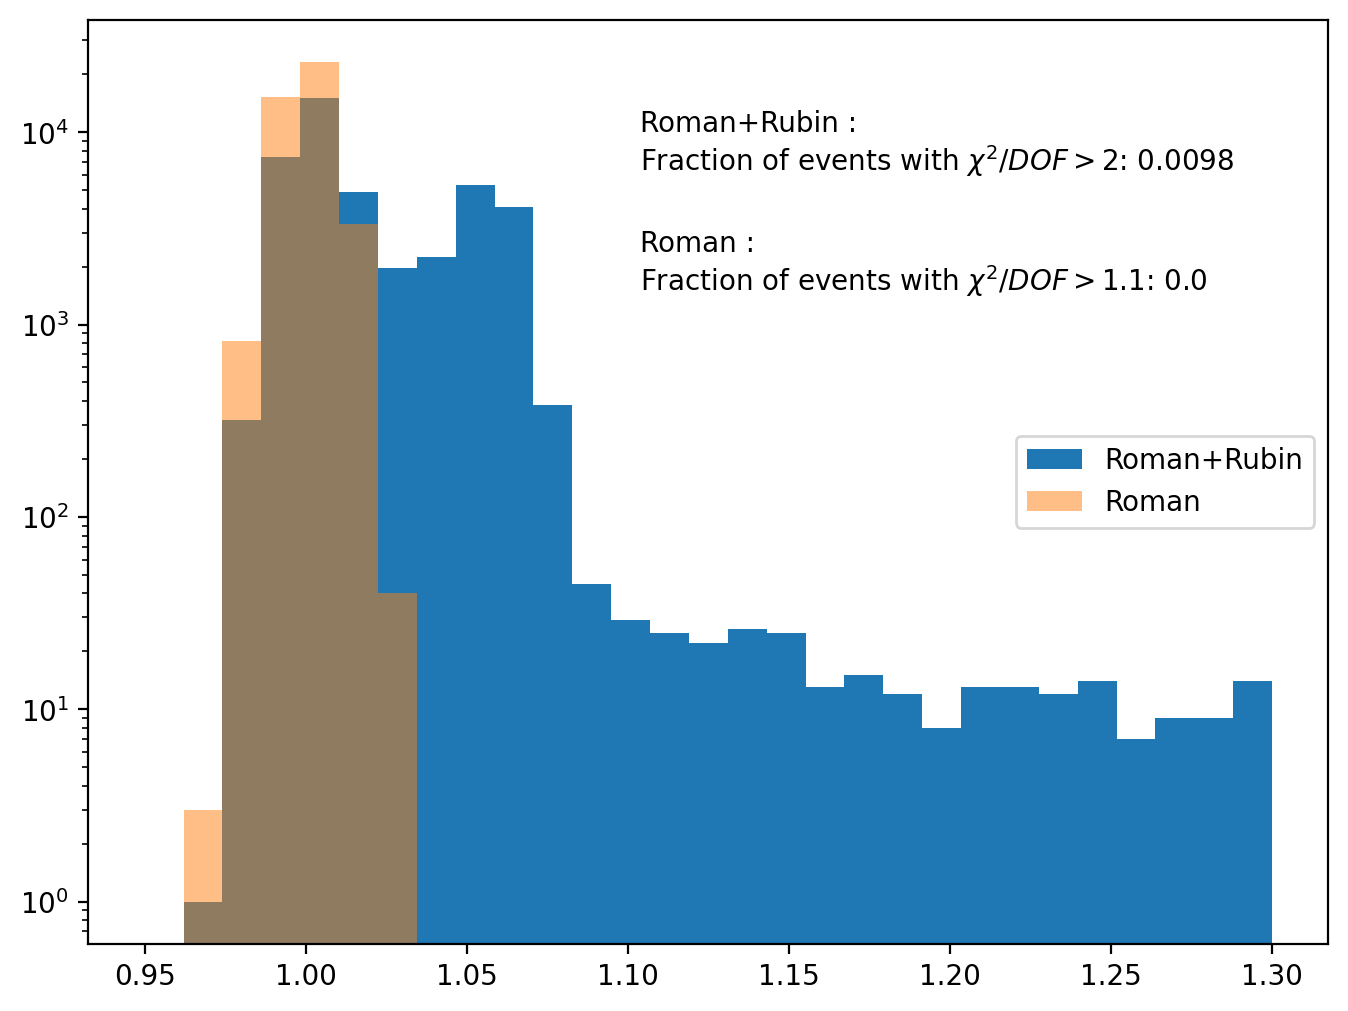

In [18]:
##
plt.close('all')
plt.figure(figsize=(8,6),dpi=200)
chi2_rr = fit_rr['chichi']/fit_rr['dof']
chi2_roman = fit_roman['chichi']/fit_roman['dof']
plt.hist(chi2_rr,bins=np.linspace(0.95,1.3,30),label='Roman+Rubin')
plt.annotate("Roman+Rubin : \n"+"Fraction of events with $\chi^2/DOF>2$: "+str(round(len(chi2_rr[chi2_rr>2])/len(chi2_rr),4)),xy=(0.4,0.7),xycoords='figure fraction')
plt.hist(chi2_roman,bins=np.linspace(0.95,1.3,30),alpha=0.5,label='Roman')
plt.annotate("Roman : \n"+"Fraction of events with $\chi^2/DOF>1.1$: "+str(round(len(chi2_roman[chi2_roman>1.1])/len(chi2_roman),4)),xy=(0.4,0.6),xycoords='figure fraction')
plt.yscale('log')
plt.legend(loc='best')
plt.show()

# Compute BIC on 3 last sets

In [19]:

def compute_BIC(Source, Set, df_fit, df_true, model, telescopes):
    '''
    telescopes: RR, Roman
    model: PSPL, USBL
    '''
    npts_roman = df_true[(df_true['Source']==Source)&(df_true['Set']==Set)]['W149'].iloc[0]
    nbands_roman = 1
    if telescopes == 'RR':
        bands_rubin = [df_true[(df_true['Source']==Source)&(df_true['Set']==Set)][f].iloc[0] for f in 'ugrizy']    
        npts_rubin =sum(bands_rubin)
        nbands_rubin = len(bands_rubin)- bands_rubin.count(0)
        nbands = nbands_rubin+nbands_roman
        npts = npts_roman+npts_rubin 
    else:
        nbands = nbands_roman
        npts = npts_roman

    if model =='USBL':
        npar = 9
    if model=='PSPL':
        npar = 5

    k = npar+2*(nbands)

    ln_L = -df_fit[(df_fit['Source']==Source)&(df_fit['Set']==Set)]['ln_likelihood'].iloc[0]
    
    BIC = k*np.log(npts)-2*ln_L

    return BIC


true_row = true[(true['Source']==13)&(true['Set']==6)]
fit_row = fit_roman[(fit_roman['Source']==13)&(fit_roman['Set']==6)]
compute_BIC(13, 6, fit_roman, true_row, 'USBL', 'Roman')
# compute_BIC(13, 6, fit_rr, true, 'USBL', 'RR')

# compute_BIC(13, 6, fit_roman_pspl, true, 'USBL', 'Roman')
# compute_BIC(13, 6, fit_rr_pspl, true, 'USBL', 'RR')

199174.95105988104

$BIC = k \ln(n)-2\ln(L)$

In [20]:
# Lista para guardar los resultados
results = []

# Iterar sobre todos los pares únicos (Source, Set) en fit_rr_pspl
for (source, set_) in fit_rr_pspl[['Source', 'Set']].drop_duplicates().itertuples(index=False):
    row_true = true[(true['Source'] == source) & (true['Set'] == set_)]
   
    if row_true.empty:
        continue
    BIC_pspl_roman = compute_BIC(source, set_, fit_roman_pspl, row_true, 'PSPL', 'Roman')
    BIC_pspl_rr = compute_BIC(source, set_, fit_roman_pspl, row_true, 'PSPL', 'Roman')
    BIC_usbl_roman = compute_BIC(source, set_, fit_roman, row_true, 'USBL', 'Roman')
    BIC_usbl_rr = compute_BIC(source, set_, fit_rr, row_true, 'USBL', 'RR')

    results.append({
        'Source': source,
        'Set': set_,
        'separation' : row_true['separation'].iloc[0],
        'u0' : row_true['u_center'].iloc[0],
        'tE' : row_true['tE'].iloc[0],
        'BIC_pspl_rr': BIC_pspl_rr,
        'BIC_usbl_rr': BIC_usbl_rr,
        'BIC_pspl_roman': BIC_pspl_roman,
        'BIC_usbl_roman': BIC_usbl_roman
    })

# Convertir a DataFrame final
df_bic = pd.DataFrame(results)
df_bic

,Source,Set,separation,u0,tE,BIC_pspl_rr,BIC_usbl_rr,BIC_pspl_roman,BIC_usbl_roman
0,42,8,0.419073,-0.000080,797.048048,106606.617531,106715.703195,106606.617531,106648.635151
1,173,8,0.201226,0.000303,70.790389,352310.669073,382613.292872,352310.669073,352353.208468
2,20,8,1.267455,-0.000329,65.620775,194875.869155,116679.663306,194875.869155,116477.867113
3,11,8,1.418063,-0.000209,20.760848,134518.421747,135093.268980,134518.421747,134560.980466
4,134,8,0.952224,0.000056,319.515294,101997.414318,64322.186578,101997.414318,64064.772742
...,...,...,...,...,...,...,...,...,...
15792,8584,6,4.303944,-0.000084,191.201901,69002.184444,66468.954020,69002.184444,66264.010747
15793,8561,6,0.422403,0.000040,337.997668,54621.559785,45998.638628,54621.559785,45748.014359
15794,8593,6,2.972604,-0.000103,34.904720,34490.115218,34670.999612,34490.115218,34532.664644
15795,8557,6,1.297260,0.000193,76.478598,95802.460466,64499.920046,95802.460466,64261.376906


In [21]:
# df_bic[df_bic['BIC_usbl_roman']<df_bic['BIC_pspl_roman']]

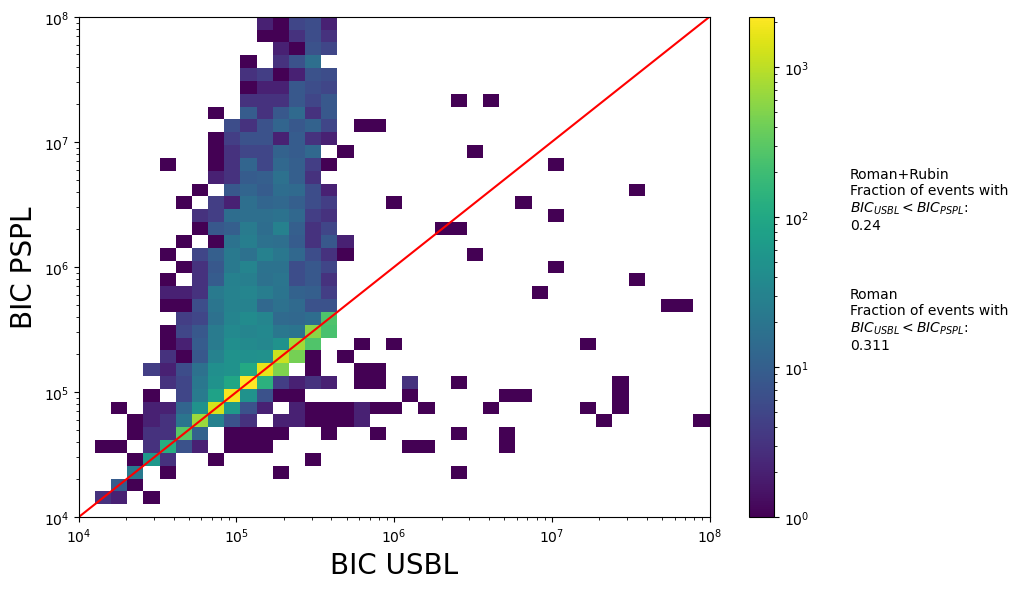

In [22]:
# %matpl
plt.close('all')
plt.figure(figsize=(10,6))
plt.hist2d(df_bic['BIC_usbl_rr'],df_bic['BIC_pspl_roman'],
           bins=(np.logspace(4,8,40),np.logspace(4,8,40)),norm=LogNorm())

plt.plot(np.logspace(4,8,40),np.logspace(4,8,40),color="red")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("BIC USBL",fontsize=20)
plt.ylabel("BIC PSPL",fontsize=20)

plt.annotate("Roman+Rubin\n"+"Fraction of events with \n"+r"$BIC_{USBL}<BIC_{PSPL}$:"+"\n"+str(round(len(df_bic[df_bic['BIC_usbl_rr']<df_bic['BIC_pspl_rr']])/len(df_bic),3)),
             xy=(0.85,0.6),
             xycoords='figure fraction')

plt.annotate("Roman\n"+"Fraction of events with \n"+r"$BIC_{USBL}<BIC_{PSPL}$:"+"\n"+str(round(len(df_bic[df_bic['BIC_usbl_roman']<df_bic['BIC_pspl_roman']])/len(df_bic),3)),
             xy=(0.85,0.4),
             xycoords='figure fraction')

plt.colorbar()
plt.tight_layout()
plt.show()

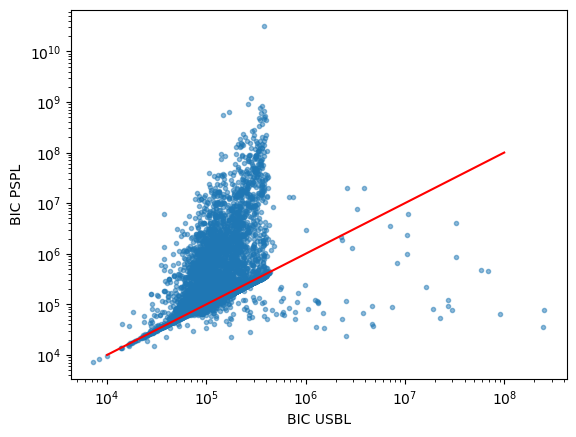

In [23]:
plt.close('all')
plt.plot(df_bic['BIC_usbl_rr'],df_bic['BIC_pspl_rr'],marker='.',ls='',alpha=0.5)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("BIC USBL")
plt.ylabel("BIC PSPL")
plt.plot(np.logspace(4,8,50),np.logspace(4,8,50),color='red')
plt.show()

In [24]:
(len(true[true['peak_flag']=='A'])+len(true[true['peak_flag']=='B'])+len(true[true['peak_flag']=='C']))==len(true)

True

In [25]:
# Define anomaly detection masks
roman_anomaly = true['anomaly_W149'] != 0
rubin_anomaly = (
    (true['anomaly_u'] != 0) |
    (true['anomaly_g'] != 0) |
    (true['anomaly_r'] != 0) |
    (true['anomaly_i'] != 0) |
    (true['anomaly_z'] != 0) |
    (true['anomaly_y'] != 0)
)

# Define categories
cat_1_mask = roman_anomaly & rubin_anomaly  # 'a'
cat_2_mask = ~roman_anomaly & rubin_anomaly # 'b'
cat_3_mask = roman_anomaly & ~rubin_anomaly # 'c'
cat_4_mask = ~roman_anomaly & ~rubin_anomaly # 'd'

# Assign flags
conditions = [cat_1_mask, cat_2_mask, cat_3_mask, cat_4_mask]
choices = ['a', 'b', 'c', 'd']
true['anomaly_flag'] = np.select(conditions, choices, default=None)


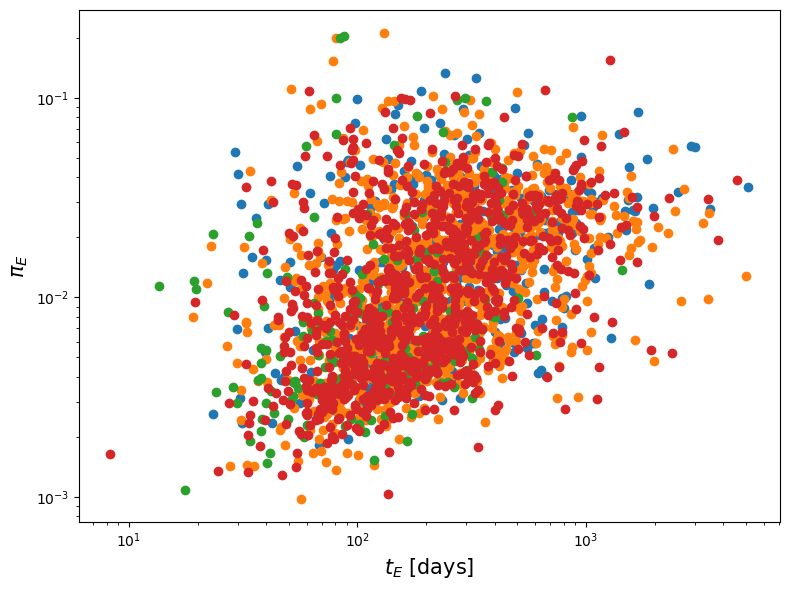

In [26]:

plt.close('all')
plt.figure(figsize=(8,6),dpi=100)
plt.scatter(true['tE'][(true['anomaly_flag']=='a')&(true['topology']=='rt')],true['piE'][(true['anomaly_flag']=='a')&(true['topology']=='rt')])
plt.scatter(true['tE'][(true['anomaly_flag']=='b')&(true['topology']=='rt')],true['piE'][(true['anomaly_flag']=='b')&(true['topology']=='rt')])
plt.scatter(true['tE'][(true['anomaly_flag']=='c')&(true['topology']=='rt')],true['piE'][(true['anomaly_flag']=='c')&(true['topology']=='rt')])
plt.scatter(true['tE'][(true['anomaly_flag']=='d')&(true['topology']=='rt')],true['piE'][(true['anomaly_flag']=='d')&(true['topology']=='rt')])
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$\pi_E$',fontsize=15)
plt.xlabel(r'$t_E$ [days]',fontsize=15)
# plt.colorbar(h[3])
plt.tight_layout()
plt.show()


In [27]:
filtered_true = true[(true['u_peak'] + true['g_peak'] + true['r_peak']+
                     true['i_peak']+true['z_peak']+true['y_peak']) > 10]

true = filtered_true
true.reset_index()

,index,Source,Set,t_center,u_center,tE,rho,separation,mass_ratio,alpha,...,W149_peak,u_peak,g_peak,r_peak,i_peak,z_peak,y_peak,peak_flag,topology,anomaly_flag
0,0,49,3,2.463018e+06,0.000110,543.283179,0.000100,0.533685,4.515395e-04,1.780921,...,16177,0,3,0,1,12,0,A,ct,b
1,1,195,3,2.462099e+06,0.000088,49.574635,0.000127,2.548135,4.081871e-04,0.746149,...,0,0,9,8,9,10,0,B,wt,d
2,4,67,3,2.461382e+06,-0.000341,116.465205,0.000129,0.940625,9.895448e-05,1.213527,...,4447,0,1,3,7,7,1,A,ct,d
3,8,118,3,2.463069e+06,0.000060,154.476368,0.000071,1.067814,1.252279e-05,2.946022,...,6336,0,16,22,63,63,2,A,wt,b
4,9,205,3,2.462810e+06,0.000083,313.740816,0.000032,0.913707,2.173932e-04,1.342477,...,20736,0,3,0,20,88,3,A,ct,c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28066,42631,8174,8,2.462336e+06,0.000649,76.389290,0.000299,1.906486,2.485843e-04,1.768705,...,0,2,57,56,87,57,1,B,wt,b
28067,42633,8182,8,2.462194e+06,0.000163,115.873293,0.000189,1.657393,7.128890e-05,1.027598,...,0,0,65,60,94,64,1,B,wt,b
28068,42634,8191,8,2.461288e+06,0.000013,152.352351,0.000049,1.278438,1.165551e-04,3.021728,...,0,0,6,9,9,11,4,B,wt,d
28069,42635,8183,8,2.462636e+06,0.000804,34.614944,0.000403,1.096066,2.223433e-07,0.639705,...,898,0,28,28,49,32,0,A,wt,d


In [28]:
# filter_fit_rr= fit_rr[fit_rr['Source'].isin(true['Source'])]
# fit_rr = filter_fit_rr#[filter_fit_rr['Set']==2]
# filter_fit_roman= fit_roman[fit_roman['Source'].isin(true['Source'])]
# fit_roman = filter_fit_roman#[filter_fit_roman['Set']==2]
# plt.hist(fit_rr['chichi']/fit_rr['dof'],bins=np.logspace(-1,1,50))
# plt.hist(fit_roman['chichi']/fit_roman['dof'],bins=np.logspace(-1,1,50))
# plt.xscale('log')
# plt.yscale('log')

In [29]:
# npts_rubin  = np.array(sum([true[f] for f in 'ugrizy']).to_list())
# len(npts_rubin[npts_rubin>3000])/len(npts_rubin)

In [30]:
# plt.hist(sum([true[f] for f in 'ugrizy']))

## True parameters and the results of the fits

In [31]:
# true.columns

In [32]:
met_1_rr, met_2_rr, met_3_rr = metrics_creator(true, fit_rr, 'USBL')
met_1_roman, met_2_roman, met_3_roman = metrics_creator(true,fit_roman,'USBL')
# met_1_rr[met_1_rr['Category_p']==1]['Source']

Filas después del merge: 28071
Filas después del merge: 28071


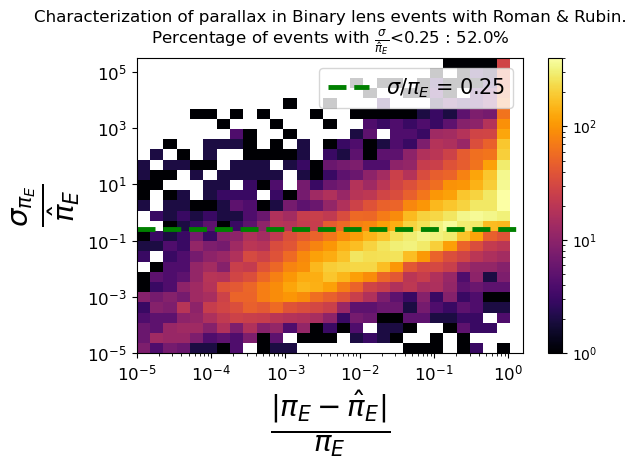

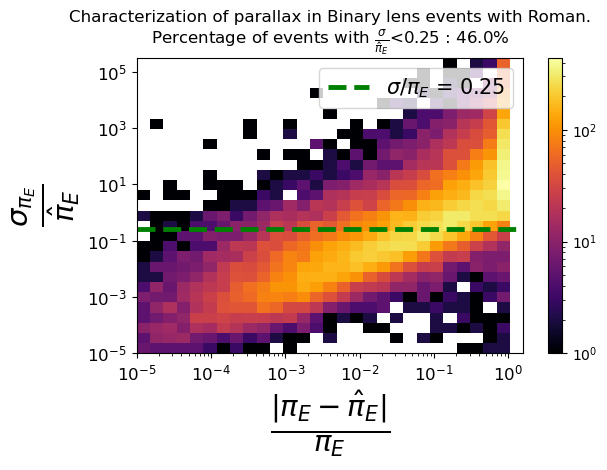

In [33]:
x = met_1_rr['piE']#[met_1_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
y = met_3_rr['piE']#[met_3_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
# mask_piE_uncertainty = met_1_rr[mask]['piE']<0.25
x = x[mask]
y = y[mask]
plt.close('all')
plt.figure(dpi=100)
h =plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-5,5.5,30)),cmap='inferno',norm=LogNorm())
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{E}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}$',fontsize=30)
plt.title('Characterization of parallax in Binary lens events with Roman & Rubin.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_E}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar(h[3])
plt.tight_layout()
plt.show()

x = met_1_roman['piE']#[met_1_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
y = met_3_roman['piE']#[met_3_rr['Source'].isin(sources_crit5pts)]#[true['crit_FFP_Rubin']==True]
mask = np.isfinite(x) & np.isfinite(y)& (x > 0) & (y > 0)
# mask_piE_uncertainty = met_1_rr[mask]['piE']<0.25
x = x[mask]
y = y[mask]
plt.close('all')
plt.figure(dpi=100)
h =plt.hist2d(x,y,bins=(np.logspace(-5,0.2,30),np.logspace(-5,5.5,30)),cmap='inferno',norm=LogNorm())
fraction = 0.25
plt.axhline(fraction,linestyle='--',color='green',linewidth=3.5,label='$\sigma/\pi_{E}$ = 0.25')
plt.xlabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}}$',fontsize=30)
plt.ylabel(r'$\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}$',fontsize=30)
plt.title('Characterization of parallax in Binary lens events with Roman.\n'+r'Percentage of events with $\frac{\sigma}{\hat{\pi}_E}$<'+f'{fraction} : '+f'{100*round(len(y[y<fraction])/len(y),2)}'+'%')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.legend(loc='best',fontsize=15)
plt.colorbar(h[3])
plt.tight_layout()
plt.show()


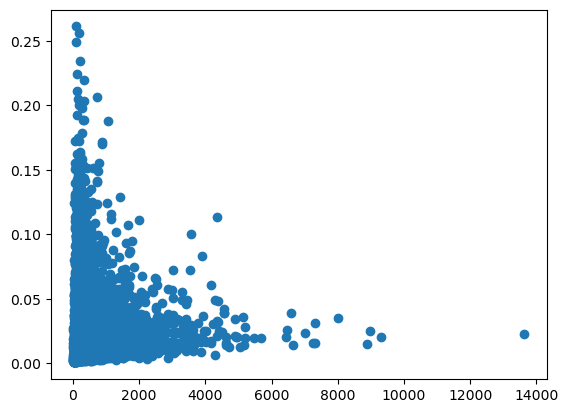

In [34]:
true = true.reset_index(drop=True)
met_3_rr = met_3_rr.reset_index(drop=True)
mask = met_3_rr['piE'] < 0.25
plt.plot(true['tE'][mask], true['piE'][mask], marker='o', linestyle='', label='Bias Roman+Rubin')


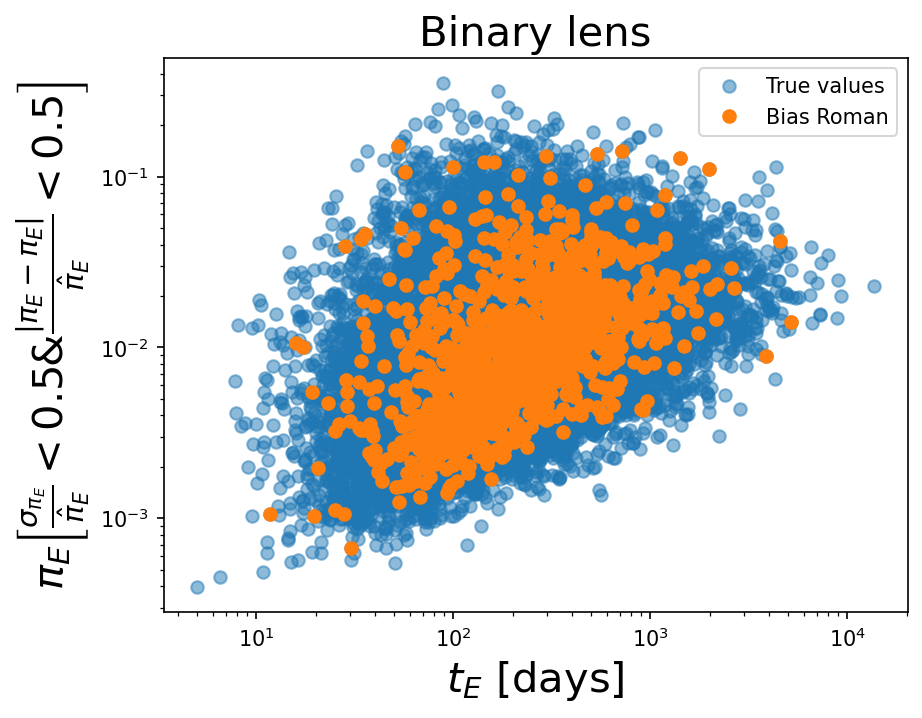

In [35]:
plt.figure(dpi=150)
plt.plot(true['tE'], true['piE'],marker='o',linestyle='',alpha=0.5,label = 'True values')#, bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.plot(true['tE'][((met_3_roman['piE']/met_3_rr['piE'])<0.5)&((met_1_roman['piE']/met_1_rr['piE'])<0.5)], true['piE'][((met_3_roman['piE']/met_3_rr['piE'])<0.5)&((met_1_roman['piE']/met_1_rr['piE'])<0.5)],marker='o',linestyle='',label = 'Bias Roman')
plt.yscale('log')
plt.xscale('log')
# plt.xlim(0,550)
# plt.ylabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.ylabel(r'$\pi_{E} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.5 & \frac{|\pi_{E}-\pi_{E}|}{\hat{\pi}_E}<0.5\right] $',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.title('Binary lens',fontsize=20)
plt.legend(loc='best')
plt.show()

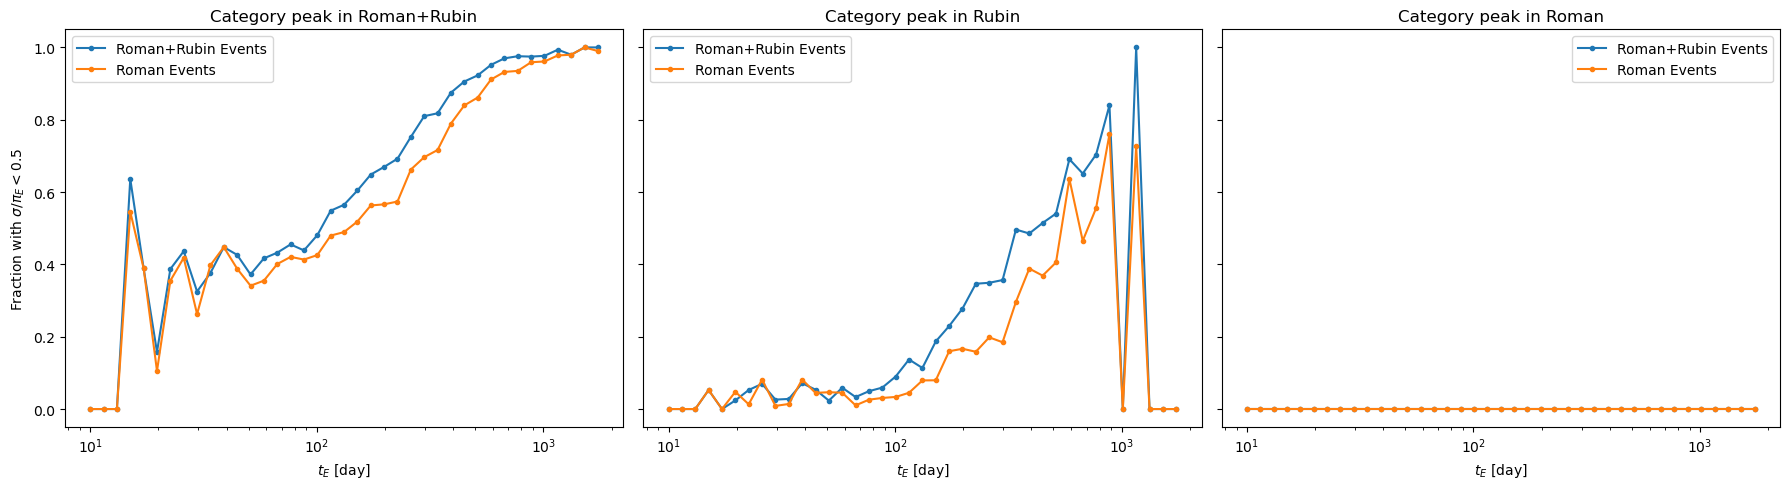

In [39]:
true_filtered = true
true_filtered_rerror = true_filtered.merge(met_3_rr[(met_3_rr['piEE']<1)][["Source","Set"]], on=['Source', 'Set'], how='inner')

df_mask = true_filtered_rerror[['Source','Set']]
met_1_rr_filtered = met_1_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_rr_filtered = met_2_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_rr_filtered = met_3_rr.merge(df_mask, on=['Source', 'Set'], how='inner')
met_1_roman_filtered = met_1_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_2_roman_filtered = met_2_roman.merge(df_mask, on=['Source', 'Set'], how='inner')
met_3_roman_filtered = met_3_roman.merge(df_mask, on=['Source', 'Set'], how='inner')

def compute_hist_ratio(hist_1, hist_2, bins):
    counts1, _ = np.histogram(hist_1, bins=bins)
    counts2, _ = np.histogram(hist_2, bins=bins)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(counts2 > 10, counts1 / counts2, 0)
    return ratio

bins = np.logspace(1, 3.3, 40)
x = bins[:-1]

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# ------------------ Categoría A (pico en Roman+Rubin) ------------------
cat = 'A'

# numerador usando met_3_rr
true_filtered_rerror = true_filtered.merge(
    met_3_rr[met_3_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

# numerador usando met_3_roman
true_filtered_rerror = true_filtered.merge(
    met_3_roman[met_3_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[0].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[0].set_xscale('log')
axs[0].set_title('Category peak in Roman+Rubin')
axs[0].set_xlabel(r'$t_E$ [day]')
axs[0].set_ylabel('Fraction with $\sigma/\pi_E < 0.5$')
axs[0].legend()

# ------------------ Categoría B (pico en Rubin) ------------------
cat = 'B'
true_filtered_rerror = true_filtered.merge(
    met_3_rr[met_3_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_3_roman[met_3_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[1].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')
axs[1].set_xscale('log')
axs[1].set_title('Category peak in Rubin')
axs[1].set_xlabel(r'$t_E$ [day]')
axs[1].legend()

# ------------------ Categoría C (pico en Roman) ------------------
cat = 'C'

true_filtered_rerror = true_filtered.merge(
    met_3_rr[met_3_rr['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
histbot = true_filtered[true_filtered['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman+Rubin Events')

true_filtered_rerror = true_filtered.merge(
    met_3_roman[met_3_roman['piE'] < 0.5][['Source', 'Set']],
    on=['Source', 'Set'], how='inner'
)
histtop = true_filtered_rerror[true_filtered_rerror['peak_flag'] == cat]['tE'].values
axs[2].plot(x, compute_hist_ratio(histtop, histbot, bins),
            marker='.', label='Roman Events')

axs[2].set_xscale('log')
axs[2].set_title('Category peak in Roman')
axs[2].set_xlabel(r'$t_E$ [day]')
axs[2].legend()

plt.tight_layout()
plt.show()


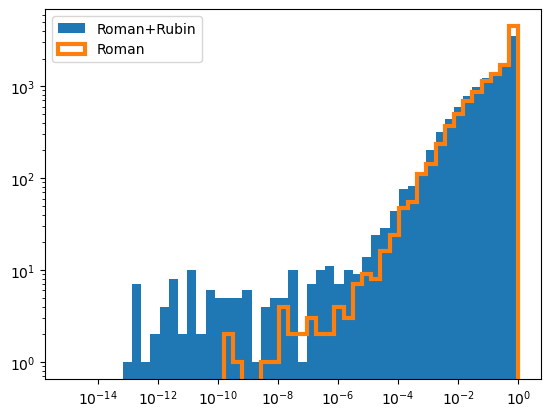

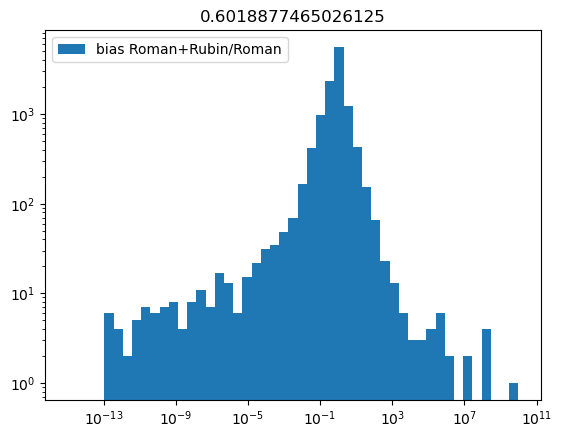

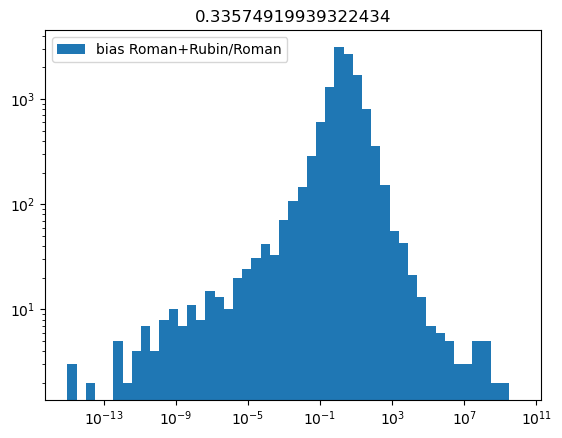

/tmp/ipykernel_218901/3216242748.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


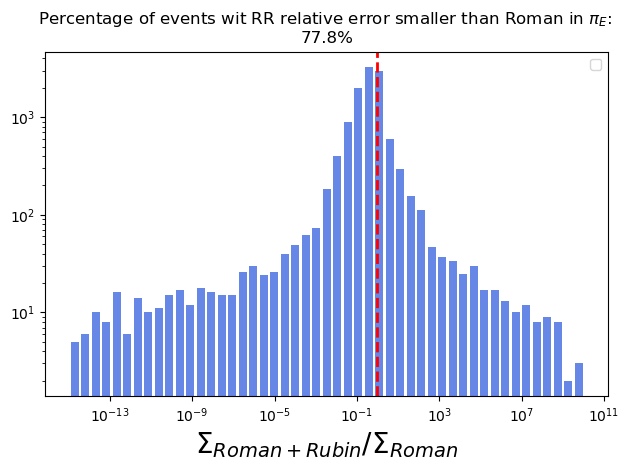

In [38]:
true[true['W149_peak']==0]['Source']

m1_rr = met_1_rr[met_1_rr['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]
m1_roman = met_1_roman[met_1_roman['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]


m2_rr = met_2_rr[met_2_rr['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]
m2_roman = met_2_roman[met_2_roman['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]


m3_rr = met_3_rr[met_3_rr['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]
m3_roman = met_3_roman[met_3_roman['Source'].isin(true[true['W149_peak']==0]['Source'].to_list())]

p='piE'
plt.figure()
plt.hist(m1_rr[p],bins=np.logspace(-15,0,50),label = 'Roman+Rubin')
plt.hist(m1_roman[p],bins=np.logspace(-15,0,50),histtype='step',linewidth=3,label = 'Roman')
plt.legend(loc='best')
plt.xscale('log')
plt.yscale('log')
plt.show()


plt.figure()
ratio = m1_rr[p]/m1_roman[p]
plt.hist(ratio,bins=np.logspace(-15,10,50),label = 'bias Roman+Rubin/Roman')
# plt.hist(m1_roman['rho'],bins=np.logspace(-15,0,50),histtype='step',label = 'Roman')
plt.title(len(ratio[ratio<1])/len(ratio))
plt.legend(loc='best')
plt.xscale('log')
plt.yscale('log')
plt.show()


plt.figure()
ratio = m2_rr[p]/m2_roman[p]
plt.hist(ratio,bins=np.logspace(-15,10,50),label = 'bias Roman+Rubin/Roman')
# plt.hist(m1_roman['rho'],bins=np.logspace(-15,0,50),histtype='step',label = 'Roman')
plt.title(len(ratio[ratio<1])/len(ratio))
plt.legend(loc='best')
plt.xscale('log')
plt.yscale('log')
plt.show()


plt.figure()
ratio = m3_rr[p]/m3_roman[p]
plt.hist(ratio,bins=np.logspace(-15,10,50),rwidth=0.8,alpha=0.8,color='royalblue')#,label = r'$\Sigma_{Roman+Rubin}/\Sigma_{Roman}$')
# plt.hist(m1_roman['rho'],bins=np.logspace(-15,0,50),histtype='step',label = 'Roman')
plt.xlabel(r'$\Sigma_{Roman+Rubin}/\Sigma_{Roman}$',fontsize=20)
plt.title(r"Percentage of events wit RR relative error smaller than Roman in $\pi_E$: "+"\n"+f"{round(len(ratio[ratio<1])/len(ratio),3)*100}%")
plt.axvline(1,color='red',linestyle='--',linewidth=2)
plt.legend(loc='best')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
path_save_fig = '/home/anibal/figures_paper_romanrubin/'
if not os.path.exists(path_save_fig):
    os.mkdir(path_save_fig)
plt.savefig(path_save_fig+'ratio_rel_err_piE.png')
plt.show()


# plt.figure()
# ratio = m3_rr[p]/m3_roman[p]
# plt.hist2d(true[true['W149_peak']==0]['tE'],ratio, bins=(np.logspace(1,3,50),np.logspace(-5,5,50)),cmap='inferno')
# # plt.hist(m1_roman['rho'],bins=np.logspace(-15,0,50),histtype='step',label = 'Roman')
# # plt.title(len(ratio[ratio>1])/len(ratio))
# plt.axhline(1,color='red',ls='--')
# plt.legend(loc='best')
# plt.xlabel('tE[day]')
# plt.xscale('log')
# plt.yscale('log')
# plt.show()

In [ ]:
true.columns

In [ ]:
true[true["peak_flag"]=="A"][["Source","Set"]]

met_1_rr

In [ ]:
plt.figure(dpi=200)
label_dict={'piE':r"$\pi_E$",
            'tE':r"$t_E$",
            'rho':r"$\rho$",
            'piEE':r'$\pi_{EE}$',
            'piEN':r'$\pi_{EN}$'}

CLR = ['k','blue','r','orange','purple','green']
label_met = ['met1','met2','met3']
# model = 'PSPL'
for k,met in enumerate([[met_1_rr,met_1_roman],[met_2_rr,met_2_roman],[met_3_rr,met_3_roman]]):
    for i,cat in enumerate(["A","B"]):
        m_rr = met[0].merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')
        m_roman = met[1].merge(true[true["peak_flag"]==cat][['Source', 'Set']], on=['Source', 'Set'], how='inner')
        if i == 0:
            line = '-'
            alph=1
        elif i==1:
            line = '--'
            alph=0.8
        elif i==2:
            line = '-.'
            alph=0.6
            
        for j,p in enumerate(['piE','tE','piEE','piEN']):
            ratio = m_rr[p]/m_roman[p]
            fraction = []
            thresh = np.linspace(0,2,100)
            for alpha in thresh:
                fraction.append(len(ratio[ratio<alpha])/len(ratio))
    
            plt.plot(thresh,fraction,color = CLR[j],linestyle=line,label=label_dict[p],alpha=alph)
            plt.xlabel("Threshold on error ratio (RR / Roman)")
            plt.ylabel('Fraction of events')
    
    
    plt.legend(loc='best',ncols=3,mode="expand",bbox_to_anchor=(0, 1.02, 1, 0.2))
    plt.tight_layout()
    # path_save_fig = '/home/anibal/figures_paper_romanrubin/'
    # plt.savefig(path_save_fig+f'threshold_{label_met[k]}_{model}.png')
    plt.show()

In [ ]:
srces = true[true['W149_peak']!=0]['Source'].to_list()
m3_rr = met_3_rr[met_3_rr['Source'].isin(srces)]
m3_roman = met_3_roman[met_3_roman['Source'].isin(srces)]

p = 'piE'
ratio = m3_rr[p]/m3_roman[p]

plt.hist(ratio, bins=np.logspace(-10,10,50))
plt.xscale('log')
plt.yscale('log')
plt.show()


In [ ]:
srces_increment_sigma = m3_rr[((m3_rr[p]/m3_roman[p])>1).to_list()]['Source'].to_list()
print(len(srces_increment_sigma))
rtio_bias = met_1_rr[met_1_rr['Source'].isin(srces_increment_sigma)][['tE','rho','mass_ratio','piEE','piEN','piE']]/met_1_roman[met_1_roman['Source'].isin(srces_increment_sigma)][['tE','rho','mass_ratio','piEE','piEN','piE']]
rtio_bias['piE']
tE_ratio = rtio_bias['piE']
tE_ratio_clean = tE_ratio[np.isfinite(tE_ratio)]

# Graficar histograma
plt.hist(tE_ratio_clean, bins=np.logspace(-3,3,50))

plt.xscale('log')
plt.xlabel('tE ratio (RR / Roman)')
plt.ylabel('Count')
plt.title('Distribution of tE Ratios: Fraction ratio of bias<1: '+str(round(len(tE_ratio_clean[tE_ratio_clean<1])/len(tE_ratio_clean),3)))
plt.grid(True)
plt.show()

In [ ]:
ratio = met_1_rr[met_1_rr['Source'].isin(srces_increment_sigma)][['tE','rho','mass_ratio','piEE','piEN','piE']]/met_1_roman[met_1_roman['Source'].isin(srces_increment_sigma)][['tE','rho','mass_ratio','piEE','piEN','piE']]
met_1_rr[met_1_rr['Source'].isin(srces_increment_sigma)][ratio['piE']>1]

In [ ]:
# met_1_rr[met_1_rr['Source']==938][['tE','rho','mass_ratio','piEE','piEN','piE']].values[0]

In [ ]:
s = 938

plt.plot(np.arange(0,6,1), met_1_rr[met_1_rr['Source']==s][['tE','rho','mass_ratio','piEE','piEN','piE']].values[0]/met_1_roman[met_1_roman['Source']==s][['tE','rho','mass_ratio','piEE','piEN','piE']].values[0],ls='',marker='o',label='Bias(Roman+Rubin)/Bias(Roman)')
# plt.plot(np.arange(0,6,1), met_1_roman[met_1_roman['Source']==899][['tE','rho','mass_ratio','piEE','piEN','piE']].values[0],ls='',marker='o',label='Roman')
plt.xticks(np.arange(0,6,1),['tE','rho','mass_ratio','piEE','piEN','piE'])
plt.legend(loc='best')

In [ ]:
info,params,curves = read_data(path_save+f'Event_{sources_array[0]}.h5')
for band in curves:
    plt.errorbar(curves[band]['time'],curves[band]['mag'],curves[band]['err_mag'], ls = '',capsize=2)

t = curves["W149"]['time']
len(t[(t<params['t0']+params['tE'])&(t>params['t0']-params['tE'])])

In [ ]:
info, event_params,curves = read_data(path_save+f'Event_{sources_array[0]}.h5')
model = 'USBL'

for band in curves:
    plt.errorbar(curves[band]['time'],curves[band]['mag'],curves[band]['err_mag'], ls = '',capsize=2)

path_to_save_fit = '/home/anibal/figures_paper_romanrubin/'
path_ephemerides = '../ephemerides/Roman_positions.npy'
from fit_lc import fit_rubin_roman
algo='TRF'

Source = sources_array[0]
rango = 1
if True:
    lc_to_fit = {}
    for telo in curves:
        if not len(curves[telo]['mag'])==0:
            df = curves[telo][['time', 'mag','err_mag']].to_pandas()
            lc_to_fit[telo] = df.values
        else:
            lc_to_fit[telo] = []
    origin = info[2]

    fit_rr_obj, event_fit_rr, pyLIMAmodel_rr = fit_rubin_roman(Source,event_params, path_to_save_fit, path_ephemerides,model,algo,origin, rango,
                               lc_to_fit["W149"], lc_to_fit["u"], lc_to_fit["g"], lc_to_fit["r"],
                                           lc_to_fit["i"], lc_to_fit["z"],lc_to_fit["y"])
    fit_roman_obj, event_fit_roman, pyLIMAmodel_roman = fit_rubin_roman(Source,event_params, path_to_save_fit, path_ephemerides,model,algo,origin,rango,
                               lc_to_fit["W149"], [], [], [], [], [],[])
    # fit_usbl, event_fit_usbl, pyLIMAmodel_usbl = fit_rubin_roman(Source,params, path_to_save_fit, path_ephemerides,'USBL',algo,origin, rango,
    #                            lc_to_fit["W149"], [],[],[],[],[],[])
    # lc_to_fit["u"], lc_to_fit["g"], lc_to_fit["r"],
                                           # lc_to_fit["i"], lc_to_fit["z"],lc_to_fit["y"])
    # fit_pspl, event_fit_pspl, pyLIMAmodel_pspl = fit_rubin_roman(Source,event_params, path_to_save_fit, path_ephemerides,'PSPL',algo,origin,rango,
    #                            lc_to_fit["W149"], [], [], [], [], [],[])
    # fit_pspl, event_fit_pspl, pyLIMAmodel_pspl = fit_rubin_roman(Source,params, path_to_save_fit, path_ephemerides,'PSPL',algo,origin, rango,
    #                            lc_to_fit["W149"], [],[],[],[],[],[])
    
    # lc_to_fit["u"], lc_to_fit["g"], lc_to_fit["r"],
    #                                        lc_to_fit["i"], lc_to_fit["z"],lc_to_fit["y"])


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner
fit_rr_obj.fit_results['best_model']
fit_roman_obj.fit_results['best_model']
fit_rr_obj.fit_results['covariance_matrix']
fit_roman_obj.fit_results['covariance_matrix']
# Recortar los primeros 7 parámetros
params_rr = fit_rr_obj.fit_results['best_model'][:9]
cov_rr = fit_rr_obj.fit_results['covariance_matrix'][:9, :9]
params_roman = fit_roman_obj.fit_results['best_model'][:9]
cov_roman = fit_roman_obj.fit_results['covariance_matrix'][:9, :9]
# Generar muestras
samples_rr = np.random.multivariate_normal(mean=params_rr, cov=cov_rr, size=10000)
samples_roman = np.random.multivariate_normal(mean=params_roman, cov=cov_roman, size=10000)

# Graficar corner plot conjunto
figure = corner.corner(
    samples_rr,
    color='blue',
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.68, 0.95),
    smooth=1.0,
    show_titles=False,
    label_kwargs={"fontsize": 12}
)

corner.corner(
    samples_roman,
    color='red',
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.68, 0.95),
    smooth=1.0,
    fig=figure
)

plt.suptitle("Comparación de parámetros Roman (rojo) vs Roman+Rubin (azul)", fontsize=14)
plt.show()



In [ ]:
plt.figure(dpi=150)
plt.plot(true['tE'][(met_3_rr['piE']<0.25)], true['piE'][met_3_rr['piE']<0.25],marker='o',linestyle='',label = 'Bias Roman+Rubin')#, bins=(np.logspace(-2,3,30),np.logspace(-6,1,30)),cmap='inferno')
plt.plot(true['tE'][(met_3_roman['piE']<0.25)], true['piE'][met_3_roman['piE']<0.25],marker='o',linestyle='',label = 'Bias Roman')
plt.yscale('log')
plt.xscale('log')
# plt.xlim(0,550)
# plt.ylabel(r'$\frac{|\pi_{E}-\hat{\pi}_{E}|}{\pi_{E}} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.ylabel(r'$\pi_{E} \left[\frac{\sigma_{\pi_{E}}}{\hat{\pi}_E}<0.25\right] $',fontsize=20)
plt.xlabel(r'$t_E$ [days]',fontsize=20)
plt.title('Binary lens',fontsize=20)
plt.legend(loc='best')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Calculate the ratio
ratio = met_1_roman['piE'][met_1_roman['Category']=='A'] / met_1_rr['piE'][met_1_roman['Category']=='A']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))
# Calculate the ratio
ratio = met_1_roman['piE'][met_1_roman['Category']=='B'] / met_1_rr['piE'][met_1_roman['Category']=='B']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),rwidth=0.9,color='royalblue',label='$[t_0- t_E,t_0+ t_E ] \cap Rubin$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))
# Calculate the ratio
ratio = met_1_roman['piE'][met_1_roman['Category']=='C'] / met_1_rr['piE'][met_1_roman['Category']=='C']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),rwidth=0.9,color='orange',label='$[t_0- t_E,t_0+ t_E ] \cap Roman$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))
plt.axvline(1, color='k',linestyle='--',linewidth=4)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\frac{|\pi_E-\hat{\pi}_E|(Roman)}{|\pi_E-\hat{\pi}_E|(RR)}$',fontsize=22)
plt.legend(loc=(0,1.01),ncols=2, mode='expand')
plt.show()

In [ ]:
# Event_Roman_16680_TRF.npy

In [ ]:

# Calculate the ratio
ratio = met_3_roman['piE'][met_1_roman['Category']=='A'] / met_3_rr['piE'][met_1_roman['Category']=='A']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

# Calculate the ratio
ratio = met_3_roman['piE'][met_1_roman['Category']=='B'] / met_3_rr['piE'][met_1_roman['Category']=='B']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),rwidth=0.9,color='royalblue',histtype='step',linewidth=5,label='$[t_0- t_E,t_0+ t_E ] \cap Rubin$ ')
print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

# Calculate the ratio
ratio = met_3_roman['piE'][met_1_roman['Category']=='C'] / met_3_rr['piE'][met_1_roman['Category']=='C']
# Remove non-finite values (NaN, inf, -inf)
clean_ratio = ratio[np.isfinite(ratio)]
# Plot the histogram
plt.hist(clean_ratio, bins=np.logspace(-6,10,20),rwidth=0.9,color='orange',label='$[t_0- t_E,t_0+ t_E ] \cap Roman$ ')
print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

plt.axvline(1, color='k',linestyle='--',linewidth=4)
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\frac{\sigma/\hat{\pi}_E(Roman)}{\sigma/\hat{\pi}_E(RR)}$',fontsize=22)
plt.legend(loc=(0,1.01),ncols=2, mode='expand')
plt.show()

In [ ]:
cat='A'

# Calculate the ratio
x = met_3_roman['piE'][met_3_roman['Category']==cat] / met_3_rr['piE'][met_3_rr['Category']==cat]
print(len(x))
# Remove non-finite values (NaN, inf, -inf)
clean_ratio0 = x[np.isfinite(x)]
# Plot the histogram
# plt.hist(clean_ratio0, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

# Calculate the ratio
y = met_1_roman['piE'][met_1_roman['Category']==cat] / met_1_rr['piE'][met_1_rr['Category']==cat]
print(len(y))
# Remove non-finite values (NaN, inf, -inf)
clean_ratio1 = y[np.isfinite(y)]
# Plot the histogram
# plt.hist(clean_ratio1, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

mask = ~np.isnan(x) & ~np.isnan(y)

x_clean = x[mask]
y_clean = y[mask]

plt.plot(x_clean,y_clean, marker='o', ls='')

plt.axvline(1,color='red')
plt.axhline(1,color='red')
plt.yscale('log')
plt.xscale('log')
print(len(y_clean))




In [ ]:
cat='A'

# Calculate the ratio
x = met_3_roman['piE'][met_3_roman['Category']==cat] / met_3_rr['piE'][met_3_rr['Category']==cat]
print(len(x))
# Remove non-finite values (NaN, inf, -inf)
clean_ratio0 = x[np.isfinite(x)]
# Plot the histogram
# plt.hist(clean_ratio0, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))




# Calculate the ratio
y = true['piE'][true['Category']==cat] #['piE'][met_1_rr['Category']==cat]
print(len(y))
# Remove non-finite values (NaN, inf, -inf)
clean_ratio1 = y[np.isfinite(y)]
# Plot the histogram
# plt.hist(clean_ratio1, bins=np.logspace(-6,10,20),color='crimson',rwidth=0.9,label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
# print(len(clean_ratio[clean_ratio>1])/len(clean_ratio))

mask = ~np.isnan(x) & ~np.isnan(y)

x_clean = x[mask]
y_clean = y[mask]

plt.plot(x_clean,y_clean, marker='o', ls='')

# plt.axvline(1,color='red')
# plt.axhline(1,color='red')
plt.yscale('log')
plt.xscale('log')
print(len(y_clean))


In [ ]:
# all(fit_roman['Source'].values==fit_rr['Source'].values[0:-1])

In [ ]:
# Suppose your column is called 'mass' in DataFrame df
# fit_rr['mass_float'] = fit_rr['mass_v1'].str.replace(' solMass', '', regex=False).astype(float)
# fit_rr['err_mass_float'] = fit_rr['err_mass_v1'].str.replace(' solMass', '', regex=False).astype(float)

# fit_roman['mass_float'] = fit_roman['mass_v1'].str.replace(' solMass', '', regex=False).astype(float)
# fit_roman['err_mass_float'] = fit_roman['err_mass_v1'].str.replace(' solMass', '', regex=False).astype(float)

In [ ]:
fit_rr = fit_rr[fit_rr['Source'].isin(fit_roman['Source'].values)]

In [ ]:
# true['Source'].values[0:-1]==fit_roman['Source'].values

In [ ]:
cat = 'A'

df_cat_roman= fit_roman[true['Category']==cat]
df_cat_rr = fit_rr[true['Category']==cat]
top = df_cat_roman['err_mass_float']/df_cat_roman['mass_float']
down = df_cat_rr['err_mass_float']/df_cat_rr['mass_float']
ratio = top/down
plt.hist(ratio[np.isfinite(ratio)],color='crimson', bins=np.logspace(-6,7,20),label='$[t_0- t_E,t_0+ t_E ] \cap Roman+Rubin$ ')
print(len(ratio[ratio>1])/len(ratio))

cat = 'B'
df_cat_roman= fit_roman[true['Category']==cat]
df_cat_rr = fit_rr[true['Category']==cat]
top = df_cat_roman['err_mass_float']/df_cat_roman['mass_float']
down = df_cat_rr['err_mass_float']/df_cat_rr['mass_float']
ratio = top/down
plt.hist(ratio[np.isfinite(ratio)],color='royalblue',histtype='step',linewidth=4, bins=np.logspace(-6,7,20),label='$[t_0- t_E,t_0+ t_E ] \cap Rubin$ ')
print(len(ratio[ratio>1])/len(ratio))

cat = 'C'
df_cat_roman= fit_roman[true['Category']==cat]
df_cat_rr = fit_rr[true['Category']==cat]
top = df_cat_roman['err_mass_float']/df_cat_roman['mass_float']
down = df_cat_rr['err_mass_float']/df_cat_rr['mass_float']
ratio = top/down
plt.hist(ratio[np.isfinite(ratio)],color='orange', bins=np.logspace(-6,7,20),label='$[t_0- t_E,t_0+ t_E ] \cap Roman$ ')
print(len(ratio[ratio>1])/len(ratio))

plt.axvline(1,color='k',ls='--',lw=3)
plt.yscale('log')
plt.xscale('log')

plt.xlabel(r'$\frac{\sigma_M/\hat{M}(Roman)}{\sigma_M/\hat{M}(RR)}$',fontsize=22)
plt.legend(loc=(0,1.01),ncols=2, mode='expand')

In [ ]:
# err_mass_data_rr = np.array([float(s.replace(' solMass', '')) for s in fit_rr['err_mass_v1'].values])
# mass_data_rr = np.array([float(s.replace(' solMass', '')) for s in fit_rr['mass_v1'].values])

# err_mass_data_roman = np.array([float(s.replace(' solMass', '')) for s in fit_roman['err_mass_v1'].values])
# mass_data_roman = np.array([float(s.replace(' solMass', '')) for s in fit_roman['mass_v1'].values])




In [ ]:
# fit_rr['err_mass_v1'].values#/fit_rr['mass_v1']

In [ ]:
# plt.hist(met_1_roman['piE']/met_1_rr['piE'])
# plt.hist(met_1_rr['piE'])

In [ ]:
# met_1_rr['piE']/met_1_roman['piE']

In [ ]:
# plt.hist(met_1_rr['t_center'])

In [ ]:
# fit_rr["piE"]=np.sqrt(fit_rr["piEE"]**2+fit_rr["piEN"]**2)
# fit_roman["piE"]=np.sqrt(fit_roman["piEE"]**2+fit_roman["piEN"]**2)
# true["piE"]=np.sqrt(true["piEE"]**2+true["piEN"]**2)

# err_ratio= pd.DataFrame(columns = true.columns)
# residuals_ratio= pd.DataFrame(columns = true.columns)
# err_ratio['id'] = true['id']
# residuals_ratio['id'] = true['id']
# for key in ['Source','Set','Category','Category_p','mass','sel_crit']:
#     err_ratio[key] = true[key]
#     residuals_ratio[key] = true[key]
# for key in ['t_center','u_center','tE','rho','separation',
#                 'mass_ratio','alpha',
#                 'piEN','piEE']:
#     if key == 't_center':
#         err_ratio[key]=abs(fit_rr[key+'_err'])/fit_roman[key+'_err']
#         residuals_ratio[key]=abs(fit_rr[key+'_err'])/fit_roman[key+'_err']
#     else:
#         err_ratio[key]=abs(fit_rr[key+'_err'])/fit_roman[key+'_err']
#         residuals_ratio[key]=abs(fit_rr[key+'_err'])/fit_roman[key+'_err']


In [ ]:
# plt.figure(figsize=(8,6),dpi=200)
# plt.hist(fit_rr['chichi']/fit_rr['dof'],edgecolor='k', bins=np.linspace(0.95,2,20), rwidth=0.8, label='Roman+Rubin')
# plt.xlabel(r'$\chi^2/dof$',fontsize=15)
# plt.hist(fit_roman['chichi']/fit_roman['dof'],edgecolor='k', bins=np.linspace(0.95,2,20), rwidth=0.8, alpha=0.5, label='Roman')
# plt.legend(loc='best',fontsize=20)
# plt.yscale("log")
# plt.yticks([1e0,1e1,1e2,1e3],[1e0,1e1,1e2,1e3],fontsize=20)
# plt.xticks([1,1.5,2],[1,1.5,2],fontsize=20)
# plt.tight_layout()
# plt.savefig('/home/anibal-pc/fig_chi2.png')
# plt.show()

## Define metrics $\alpha$, $\beta$, $\gamma$

In [ ]:
columns_to_check = ['t_center', 'tE', 'rho', 'piEE', 'separation', 'mass_ratio', 'alpha', 'piEN', 'u_center']

fig, axs = plt.subplots(3, 3, figsize=(20, 10), dpi=200)
axs = axs.flatten()

# Elegimos solo una categoría
category = 'B' #'B'

# colors = {1:'#1f77b4',2: '#ff7f0e',3: '#2ca02c'}  # Azul, naranja, verde
colors = {'A':'#1f77b4','B': '#ff7f0e','C': '#2ca02c'}  # Azul, naranja, verde
color = colors[category]  # azul para ambas datasets con distinta transparencia

example_handles = []
example_labels = []

for i, p in enumerate(columns_to_check):
    ax = axs[i]

    # Filtrar datos por esa categoría & tE<50 days
    data_rr = met_1_rr[(met_1_rr['Category'] == category)&(true['tE']<50)][p]
    data_roman = met_1_roman[(met_1_roman['Category'] == category)&(true['tE']<50)][p]

    # Histogramas para RR (más opaco) y Roman (más transparente)
    ax.hist(data_rr, bins=20, label=f'RR-{category}', color='orange', alpha=0.7,rwidth=0.8)
    ax.hist(data_roman, bins=20, label=f'Roman-{category}', color='royalblue', alpha=0.8, histtype='step',linewidth=2.5,rwidth=0.8)

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        example_handles = handles
        example_labels = labels

    # Métrica < 0.25
    frac_rr = round(len(data_rr[data_rr < 0.25]) / len(data_rr), 3)
    frac_roman = round(len(data_roman[data_roman < 0.25]) / len(data_roman), 3)

    param_latex = lambda p: fr"$\frac{{\left|{{\text{{{p}}}}}^{{\text{{fit}}}} - {{\text{{{p}}}}}^{{\text{{true}}}}\right|}}{{{{\text{{{p}}}}}^{{\text{{true}}}}}}$"

    ax.set_xlabel(param_latex(columns_to_check[i]), fontsize=16)

    ax.set_title(
        fr"Fraction of events with the metric {param_latex(columns_to_check[i])} < 0.25"+f'\nRoman+Rubin: {frac_rr}\nRoman: {frac_roman}',
        fontsize=14,
        # y=1.08
    )
    ax.set_yscale("log")
fig.legend(example_handles, example_labels, loc='upper center', ncol=2, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.005))
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

In [ ]:
fig, axs = plt.subplots(3,3,figsize=(20,10),dpi=200)
axs = axs.flatten()
for i,p in enumerate(columns_to_check):
    ax = axs[i]

    cat= 'B'
    ax.hist(met_1_rr[p][met_1_rr['Category']==cat],label='Roman+Rubin')
    ax.set_title('metric<0.5\nR+R:'+str(round(len(met_1_rr[met_1_rr[p]<0.5][met_1_rr['Category']==cat])/len(met_1_rr[p][met_1_rr['Category']==cat]),3))+'\n Roman:'+str(round(len(met_1_roman[met_1_roman[p]<0.5][met_1_rr['Category']=='A'])/len(met_1_roman[p][met_1_rr['Category']==cat]),3)))
    ax.hist(met_1_roman[p][met_1_rr['Category']==cat],alpha=0.7,label='Roman')
    # plt.title()
    ax.set_xlabel(p, fontsize=20)
    # ax.set_ylabel(p)
    ax.legend()
plt.suptitle(r'$\frac{|fit-true|}{true}$',fontsize=30)
plt.tight_layout()

In [ ]:
fig, axs = plt.subplots(3,3,figsize=(20,10),dpi=200)
axs = axs.flatten()
for i,p in enumerate(columns_to_check):
    ax = axs[i]
    ax.hist(met_3_rr[p],bins = np.linspace(0,10,30),label='Roman+Rubin')
    ax.hist(met_3_roman[p],bins = np.linspace(0,10,30),alpha=0.7,label='Roman')
    ax.set_xlabel(p, fontsize=20)
    # ax.set_xscale('log')
    ax.legend()
plt.suptitle(r'$\frac{|\sigma|}{Fit}$',fontsize=30)
plt.tight_layout()

In [ ]:

fig, axs = plt.subplots(3,3,figsize=(20,10),dpi=200)
axs = axs.flatten()
for i,p in enumerate(columns_to_check):
    ax = axs[i]
    ax.hist(met_2_rr[p],bins = np.linspace(0,10,30),label='Roman+Rubin')
    ax.hist(met_2_roman[p],bins = np.linspace(0,10,30),alpha=0.7,label='Roman')
    ax.set_xlabel(p, fontsize=20)
    # ax.set_ylabel(p)
    ax.legend()
plt.suptitle(r'$\frac{|fit-true|}{\sigma}$',fontsize=30)

plt.tight_layout()

## Focus only on the good events
Defined as those that dont hit the boundaries of the region given to maximize the likelihood during the estimation of the parameters.

In [ ]:
# Columns to consider for exclusion criteria
columns_to_check = [ 'tE','rho','piEE','separation','mass_ratio','alpha','piEN','u_center']
df =met_1_rr
# Exclude rows where the specified columns have values between 0 and 1
# df = met_1_rr

def filter_df(df):
    '''
    remove rows where any of the specified columns (columns_to_check) contain values between 0.97 and 1.16
    '''
    filtered_df = df#[((df[columns_to_check] > 0.97) & (df[columns_to_check] < 1.16)).any(axis=1)]
    return filtered_df

df = met_1_roman
filtered_df = df[~((df[columns_to_check] > 0.97) & (df[columns_to_check] < 1.16)).any(axis=1)]
source_roman = filtered_df['id']
source_rr = filtered_df['id']
# source_rr = filtered_df['id']
source_intersection = source_rr[source_rr.isin(source_roman)]
# source_intersection = true['id']

In [ ]:
met_1_rr_fil = filter_df(met_1_rr)
met_1_rr_fil[met_1_rr_fil['sel_crit']==True]

In [ ]:
# Find rows where ALL values in columns_to_check are within the range
# rows_in_rr = met_1_rr[((met_1_rr[columns_to_check] > 0.97) & (met_1_rr[columns_to_check] < 1.16)).all(axis=1)]
# rows_in_roman = met_1_roman[((met_1_roman[columns_to_check] > 0.97) & (met_1_roman[columns_to_check] < 1.16)).all(axis=1)]
# print(len(rows_in_rr[rows_in_rr['sel_crit']==True]))
# print(len(rows_in_rr[rows_in_rr['sel_crit']==False]))

In [ ]:
# true = true[true['id'].isin(source_intersection)]
# fit_rr = fit_rr[fit_rr['id'].isin(source_intersection)]
# fit_roman = fit_roman[fit_roman['id'].isin(source_intersection)]
# met_1_rr = met_1_rr[met_1_rr['id'].isin(source_intersection)]
# met_2_rr = met_2_rr[met_2_rr['id'].isin(source_intersection)]
# met_3_rr = met_3_rr[met_3_rr['id'].isin(source_intersection)]
# met_1_roman = met_1_roman[met_1_roman['id'].isin(source_intersection)]
# met_2_roman =  met_2_roman[met_2_roman['id'].isin(source_intersection)]
# met_3_roman = met_3_roman[met_3_roman['id'].isin(source_intersection)]
# err_ratio = err_ratio[err_ratio['id'].isin(source_intersection)]
# residuals_ratio = residuals_ratio[residuals_ratio['id'].isin(source_intersection)]

In [ ]:
# plt.hist(met_1_rr['te'])

In [ ]:
# true

In [ ]:
# print(set(true['Category']))
# print(len(true[true['Category']=='A']))
# print(len(true[true['Category']=='B']))
# print(len(true[true['Category']=='C']))

# Plots

## True parameters as distributions

In [ ]:
# fit_rr[p]

In [ ]:
# fit_roman[p]

In [ ]:
abs(min(true['t_center'])-max(true['t_center']))/365.25

In [ ]:
# p='u0'
# plt.hist(true[p], bins=30,alpha=0.4, label='True')
# plt.hist(fit_rr[p], bins=30, histtype='step', lw=3, label='Fit RR')
# plt.hist(fit_roman[p], bins=30, histtype='step', lw=3, label='Fit Roman')

In [ ]:
params = ['t_center', 'u_center', 'tE', 'rho', 'separation', 'mass_ratio', 'alpha', 'piEE', 'piEN']

# Create subplots
n_rows = 3  # Number of rows in the grid
n_cols = 3  # Number of columns in the grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), constrained_layout=True)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through parameters and corresponding axes
for i, p in enumerate(params):
    ax = axes[i]
    ax.hist(true[p], alpha=0.4, label='True')
    ax.hist(fit_rr[p], histtype='step', lw=3, label='Fit RR')
    ax.hist(fit_roman[p], histtype='step', lw=3, label='Fit Roman')
    if p =='mass_ratio':
        ax.set_xticks([0,0.01,0.02])
    ax.set_yscale('log')
    ax.set_xlabel(p)
    ax.legend()

# Remove empty subplots (if any)
for i in range(len(params), len(axes)):
    fig.delaxes(axes[i])

# Show the final grid of histograms
plt.show()


## Estimated values

In [ ]:
labelsparams = lambda p: labels[p]
label_m3 = lambda p :r'$\frac{\sigma_{'+f'{labels[p]}'+'}}{'+f'{labels[p]}'+'^{fit}}$'#+f'{labels[p]}'+'}}$'
label_m2 = lambda p :r'$\frac{|'+f'{labels[p]}'+'^{true}-'+f'{labels[p]}'+'^{fit}|}{\sigma_{'+f'{labels[p]}'+'}}$'

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1]})

q='tE'
p = 'mass_ratio'
r = 'separation'
ax.plot(true[p], true[r], marker='o', ls='') #,bins=np.linspace(min(true[q]), max(true[q]),15))
ax.plot(true[p][true['id'].isin(err_ratio['id'][err_ratio[p]<0.25])], true[r][true['id'].isin(err_ratio['id'][err_ratio[p]<0.25])], marker='x',ls='',color='red',label='Events with\n'+r'$\frac{\sigma(q)_{RR}}{\sigma(q)_{Roman}}<0.25$')#,bins=np.linspace(min(true[q]), max(true[q]),15))
ax.set_xlabel(r'$q$',fontsize=20)
ax.set_ylabel(r'$s$',fontsize=20)
ax.set_xlim(0,0.01)
ax.set_ylim(0,10)

ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)

# Histogram settings
#binwidth = 0.1
ax_histx.hist(true[p], bins=np.arange(0, 0.01, 0.0005), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue')
ax_histx.hist(true[p][true['id'].isin(err_ratio['id'][err_ratio[p]<0.25])], bins=np.arange(0, 0.01, 0.0005), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='crimson')

ax_histy.hist(true[r], bins=np.arange(0, 18, 1), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')
ax_histy.hist(true[r][true['id'].isin(err_ratio['id'][err_ratio[p]<0.25])], bins=np.arange(0, 18, 1), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='crimson', orientation='horizontal')

ax_histy.set_xscale("log")
ax_histx.set_yscale("log")

# Remove ticks from inset histograms
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.tick_params(axis="y", left=False, labelleft=False)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
ax.legend(loc='best',fontsize=20)


## Metrics

### Functions to create plots

In [ ]:
def create_hist2d_with_marginals(ax, x, y, labels, p, first_col=False):

    tex_label = {'t0':'t_0', 'u0':'u_0', 'te':'t_E','rho':'\\rho', 's':'s', 'q':'q', 'alpha':'\\alpha', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}
    # Main scatter plot
    hb = ax.hist2d(x, y, bins=(np.arange(0, 1.9, 0.1), np.arange(0, 1.9, 0.1)), cmap='Greens')
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)

    # Create inset axes for the histograms
    ax_histx = ax.inset_axes([0, 1.05, 1, 0.2], sharex=ax)
    ax_histy = ax.inset_axes([1.05, 0, 0.2, 1], sharey=ax)

    # Histogram settings
    binwidth = 0.1
    ax_histx.hist(x, bins=np.arange(0, 1.8, binwidth), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='red')
    ax_histy.hist(y, bins=np.arange(0, 1.8, binwidth), density=True, histtype='stepfilled', edgecolor='k', fill=True, alpha=0.5, color='royalblue', orientation='horizontal')

    # Remove ticks from inset histograms
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histx.tick_params(axis="y", left=False, labelleft=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    ax_histy.tick_params(axis="x", bottom=False, labelbottom=False)
    # ax_histy.set_yscale("log")
    # Add vertical and horizontal lines
    ax_histx.axvline(1, color='red', ls='--')
    ax_histy.axhline(1, color='red', ls='--')
    ax.axvline(1, ymin=0, ymax=0.5, lw=2, color='red')
    ax.axvline(0, ymin=0, ymax=0.5, lw=2, color='red')
    ax.axhline(0, xmin=0, xmax=0.5, lw=2, color='red')
    ax.axhline(1, xmin=0, xmax=0.5, lw=2, color='red')

    # Set labels with LaTeX formatting
    # label_m1 = lambda p: r'$\frac{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{RR}}{|' + f'{labels[p]}' + r'^{true}-' + f'{labels[p]}' + r'^{fit}|_{R}}$'
    # label_m2 = r'$\frac{\sigma_{RR}}{\sigma_{Roman}}$'
    labelx, labely =labels[0],labels[1]
    ax.set_xlabel(labelx, fontsize=20)
    
    # ax.set_xlabel("a",fontsize=20)
    # if first_col:
    ax.set_ylabel(labely, fontsize=20)

    # Add a colorbar inside the main plot
    cax = ax.inset_axes([0.85, 0.05, 0.03, 0.35], transform=ax.transAxes)
    cbar = plt.colorbar(hb[3], cax=cax, orientation='vertical')
    # cax.set_yticks([0, 50, 1000])
    # cax.set_yticklabels([0, 100, 2000], fontsize=8)
    x_min=0
    x_max=1
    y_min=0
    y_max=1
    fil_x= x[(y<1)&(y>0)]
    filtered=fil_x[(fil_x<1)&(fil_x>0)]

    number_in_square = len(filtered)/len(y)
    text = f"Fraction of events\n in [{x_min},{x_max}] x [{y_min},{y_max}]= {round(number_in_square ,2)}"  # Insert the number here
    ax.set_title(text, fontsize = 16)


def plot_histogram(ax, DATA, p, colors, some_flag=False):
    # print(data)
    sources = DATA['Source'].values
    data = DATA[p]   
    lab_latex = {'tE':'tE(days)','rho':'\\rho' ,'piE':'\pi_E','mass_ratio':'q'}
    data_label = lab_latex[p]
    lab_latex_legend = {'tE':'t_E','rho':'\\rho','piE':'\pi_E','mass_ratio':'q'}
    xlabel=r'$log_{10}'+f"[{lab_latex[p]}]$"
    
    masks_rr = lambda p, label: [
        (met_1_rr[p][met_1_rr['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_rr[p][met_2_rr['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_rr[p][met_3_rr['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    masks_roman = lambda p, label:[
        (met_1_roman[p][met_1_roman['Source'].isin(sources)] < 0.25, 'r', f"$\\alpha({label})<0.25$"),
        (met_2_roman[p][met_2_roman['Source'].isin(sources)] < 0.25, 'k', f"$\\beta({label})<0.25$"),
        (met_3_roman[p][met_3_roman['Source'].isin(sources)] < 0.25, 'g', f"$\\gamma({label})<0.25$"),
    ]
    
    if some_flag:
        masks = masks_roman(p,lab_latex_legend[p])
        dataset = 'Roman'
        met_1 = met_1_roman[met_1_roman['Source'].isin(sources)]
        met_2 = met_2_roman[met_2_roman['Source'].isin(sources)]
        met_3 = met_3_roman[met_3_roman['Source'].isin(sources)]
    else:
        masks = masks_rr(p,lab_latex_legend[p])
        dataset = 'Roman and Rubin'
        met_1 = met_1_rr[met_1_rr['Source'].isin(sources)]
        met_2 = met_2_rr[met_2_rr['Source'].isin(sources)]
        met_3 = met_3_rr[met_3_rr['Source'].isin(sources)]

    # Plot the histogram of the true values
    ax.hist(np.log10(data), bins=30, color='royalblue', alpha=0.5, label=f'True value of ${lab_latex_legend[p]}$')
    
    # Iterate over the masks and plot the masked data

    for (mask, color, label) in masks:
        mask = mask.reindex(data.index, fill_value=False)
        
        masked_data = data[mask]
        ax.hist(np.log10(masked_data), 
                bins=30, histtype='step', color=color, lw=2, label=label)
    
    # Set labels and title
    # print(xlabel)


    ax.set_xlabel(xlabel, fontsize=20)
    
    ax.set_title('Percentage of events with:\n'+
                 f"$\\alpha({lab_latex_legend[p]})<0.25: $"+
                 f"{round(100*len(met_1[p][met_1[p]<0.25])/len(data),2)}%, "+'\n'+
                 f"$\\beta({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_2[p][met_2[p]<0.25])/len(data),1)}%, "+'\n'+
                 f"$\\gamma({lab_latex_legend[p]})<0.25: $"+f"{round(100*len(met_3[p][met_3[p]<0.25])/len(data),2)}%",fontsize=15)
    ax.legend(fontsize=10)
    # ax.set_xticks([1,2,3,4],fontsize=12)
    
    ax.grid()

## Histograms 2D metrics and metrics ratio

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1,1, 1]})
x = residuals_ratio['tE'][residuals_ratio["id"].isin(source_rr)]
y = err_ratio['tE'][err_ratio["id"].isin(source_rr)]
x2 = residuals_ratio['rho'][residuals_ratio["id"].isin(source_rr)]
y2 = err_ratio['rho'][err_ratio["id"].isin(source_rr)]
x3 = residuals_ratio['piE'][residuals_ratio["id"].isin(source_rr)]
y3 = err_ratio['piE'][err_ratio["id"].isin(source_rr)]
print(len(x3))

create_hist2d_with_marginals(axes[0], x, y, ["$\\frac{|t_E^{Fit}-t_E^{True}|_{RR} }{ |t_E^{Fit}-t_E^{True}|_{Roman}}$","$\\sigma_{RR}/\\sigma_{Roman}$"], 'te', first_col=True)
create_hist2d_with_marginals(axes[1], x2, y2, ["$\\frac{|\\rho^{Fit}-\\rho^{True}|_{RR} }{ |\\rho^{Fit}-\\rho^{True}|_{Roman}}$","$\\sigma_{RR}/\\sigma_{Roman}$"], 'rho')
create_hist2d_with_marginals(axes[2], x3, y3, ["$\\frac{|\\pi_E^{Fit}-\\pi_E^{True}|_{RR} }{ |\\pi_E^{Fit}-\\pi_E^{True}|_{Roman}}$","$\\sigma_{RR}/\\sigma_{Roman}$"], 'piE')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True, gridspec_kw={'width_ratios': [1,1, 1]})
x = met_1_rr['tE']
y = met_2_rr['tE']
x2 = met_2_rr['tE']
y2 = met_3_rr['tE']
x3 = met_1_rr['piE']
y3 = met_3_rr['piE']
# print(x3)
labels = {'t_center':'t_0', 'u_center':'u_0', 'tE':'t_E','rho':'\\rho', 's':'s', 'q':'q', 'alpha':'\\alpha', 'piE':'\pi_{E}', 'piEN':'\pi_{EN}'}

p='tE'
create_hist2d_with_marginals(axes[0], x, y, ['$\\alpha$'+f"(${labels[p]}$)",r'$\beta$'+f"(${labels[p]}$)"], p, first_col=True)
create_hist2d_with_marginals(axes[1], x2, y2, ['$\\beta$'+f"(${labels[p]}$)",r'$\gamma$'+f"(${labels[p]}$)"], p)
create_hist2d_with_marginals(axes[2], x3, y3, ['$\\alpha$'+f"(${labels[p]}$)",r'$\gamma$'+f"(${labels[p]}$)"], p)

plt.tight_layout()
plt.show()

In [ ]:
# len(set(fit_rr['Source'][fit_rr['p_value']>0.05]).intersection(set(fit_roman['Source'][fit_roman['p_value']>0.05])))

## Histograms true parameters and overlap histograms of the estimated parameters from fits

The fraction of events below certain thresholds is included in the graph.

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(25, 12), gridspec_kw={'hspace': 0.65})
cat = 'A'
mask = (true["categories"] == cat) #& (true['Source'].isin(fit_rr['Source'][fit_rr['p_value']>0.05].values))
# mask = np.ones(len(true),dtype=bool)

true_df=true[mask]
# print(true_df)
# display(true_df)
# print(fit_rr['p_value'][fit_rr['Source']==5035])
# Plotting histograms

p = 'tE'
plot_histogram(axes[0, 0], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 0], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
p = 'rho'
plot_histogram(axes[0, 1], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 1], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
p = 'piE'
plot_histogram(axes[0, 2], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 2], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
p = 'mass_ratio'
plot_histogram(axes[0, 3], true_df, p, colors=['k', 'r', 'g'], some_flag=False)
plot_histogram(axes[1, 3], true_df, p, colors=['k', 'r', 'g'], some_flag=True)
cats_label = {'A':'Overlap of the Observing Seasons of Roman and Rubin', 'B':'Rubin Season and Roman Gap', 'C':'Roman Season and Rubin Gap', 'D':'Roman Gap and Rubin gap'}
# Add titles for each row
fig.text(0.5, 1, 'Binary lens model - Planetary systems \n$t_0 \pm t_E$ in the '+ cats_label[cat]+'\n Roman and Rubin data', ha='center', fontsize=25)
fig.text(0.5, 0.51, 'Roman simulated data', ha='center', fontsize=25)
# Add common Y label
fig.text(0.1-0.01, 0.5, 'N events', va='center', rotation='vertical', fontsize=25)
plt.tight_layout()# Adjust the layout to avoid overlapping


In [ ]:
# plt.hist2d(np.log10(true['te']),np.log10(true['piE']),bins=30)
# plt.show()

In [ ]:
# print(100*len(met_1_rr["rho"][met_1_rr["rho"]<0.25])/len(met_1_rr))

## Histograms of metrics $\alpha$, $\beta$ and $\gamma$ by categories

In [ ]:
labelsparams = lambda p: labels[p]

label_m1 = lambda p: f'$\\alpha({labels[p]})$'
label_m3 = lambda p :f'$\\gamma({labels[p]})$'
label_m2 = lambda p :f'$\\beta({labels[p]})$'

# cats_label = {'A':'Overlap of the Observing Seasons of Roman and Rubin', 'B':'Rubin Season and Roman Gap', 'C':'Roman Season and Rubin Gap', 'D':'Roman Gap and Rubin gap'}
# cats_labels = {'A': 'Overlap seasons Roman and Rubin', 'B': 'Roman gap and Rubin season','C': 'gap Roman and gap Rubin', 'D': 'Season Roman and gap Rubin'}
# Function to plot histograms and annotations

def plot_histogram(ax, data1, data2, xlabel, title,limit):
    # ax.set_title(title)
    ax.hist(data1, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman+Rubin')
    ax.hist(data2, bins=np.arange(0, 1.1, 0.1), edgecolor="k",lw=0.2, alpha=0.4, label='Roman')
    ax.set_xlabel(xlabel, fontsize=20)
    ax.axvline(limit, color='red', linestyle='--')
    ax.legend(loc='best')
    
    fraction_data1 = len(data1[data1 < limit]) / len(data1)
    fraction_data2 = len(data2[data2 < limit]) / len(data2)
    
    ax.annotate(f'Fraction of events Roman+Rubin\nwith {xlabel}<{str(limit)} = {fraction_data1:.2f}', 
                xy=(0.5, -0.3), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)
    ax.annotate(f'Fraction of events Roman\nwith {xlabel}<{str(limit)} = {fraction_data2:.2f}', 
                xy=(0.5, -0.45), xycoords='axes fraction',
                ha='center', va='center', fontsize=15)
    
categories = ['A', 'B']
datasets = [(met_1_rr, met_1_roman), (met_2_rr, met_2_roman), (met_3_rr, met_3_roman)]
label_functions = [label_m1, label_m2, label_m3]  # Corresponding label functions for each dataset

# Define the limit values for each label function
limits = {label_m1: 0.1, label_m2: 1, label_m3: 0.25}

# Parameters for the histograms
params = [('tE', r'$t_E$'), ('rho', r'$\rho$'), ('piE', r'$\pi_E$')]
p='tE'
# Loop through the datasets and categories
for i, (rr, roman) in enumerate(datasets):
    label_func = label_functions[i]  # Dynamically choose the correct label function
    limit = limits[label_func]  # Set the limit based on the label function
    
    for cat in categories:
        fig, axes = plt.subplots(1, 3, figsize=(18, 7))

        # Add a title for the figure
        plt.suptitle(f'Category: {cats_label[cat]}')# (Dataset {i+1})')

        # Filter based on the category
        mask_rr = rr['id'].isin(true['id'][true['categories'] == cat])
        mask_roman = roman['id'].isin(true['id'][true['categories'] == cat])
        mask_rr = mask_rr.reindex(rr[p].index, fill_value=False)
        mask_roman = mask_roman.reindex(roman[p].index, fill_value=False)
        
        # Loop through the parameters for each axis
        for j, (p, label) in enumerate(params):
            plot_histogram(axes[j], rr[p][mask_rr], roman[p][mask_roman], label_func(p), label, limit)

        # Add grids and adjust the layout
        for ax in axes:
            ax.grid()
        plt.tight_layout()

        # Show the plot
        plt.show()


## Corner plot 

This plot give some idea of the correlation between parameters

In [ ]:

# Corner plot settings
# CORNER_KWARGS = dict(
#     smooth=0.9,
#     label_kwargs=dict(fontsize=16),
#     title_kwargs=dict(fontsize=12),
#     quantiles=[0.16, 0.84],
#     levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
#     plot_density=False,
#     plot_datapoints=False,
#     fill_contours=True,
#     show_titles=True,
#     max_n_ticks=3,
# )
# Corner plot settings with corrected quantiles
CORNER_KWARGS = dict(
    smooth=0.9,
    label_kwargs=dict(fontsize=16),
    title_kwargs=dict(fontsize=12),
    # quantiles=[0.16, 0.5, 0.84],  # Added median (0.5) to make it length-3
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.)),
    plot_density=False,
    plot_datapoints=False,
    fill_contours=True,
    show_titles=True,
    max_n_ticks=3,
)


def remove_nonfinite_values(arrays):
    """Remove non-finite (NaN, inf) values from a list of arrays."""
    cleaned_arrays = []
    for array in arrays:
        finite_mask = np.isfinite(array)
        cleaned_arrays.append(array[finite_mask])
    return cleaned_arrays

def overlaid_corner(samples_list, sample_labels, axis_labels, cat):
    """Plots multiple corner plots on top of each other with axis labels."""
    
    category_title = {'A':'Overlap seasons', 'B':'Season Roman and gap Rubin', 'C':'Season Rubin and gap Roman', 'D':'Gap Roman and gap Rubin'}
    # Get constants for plotting
    n = len(samples_list)
    _, ndim = samples_list[0].shape
    max_len = max([len(s) for s in samples_list])
    cmap = plt.colormaps['viridis']  # Updated for Matplotlib 3.7+
    colors = [cmap(i / (n - 1)) for i in range(n)]  # Generate distinct colors

    plot_range = []
    for dim in range(ndim):
        plot_range.append(
            [
                min([min(samples_list[i].T[dim]) for i in range(n)]),
                max([max(samples_list[i].T[dim]) for i in range(n)]),
            ]
        )

    CORNER_KWARGS.update(range=plot_range, labels=axis_labels, label_kwargs=dict(labelpad=15))  # Add label padding

    # Create the first corner plot with better figure size control
    fig = plt.figure(figsize=(8, 8))  # Slightly larger for better label management
    corner.corner(
        samples_list[0],
        fig=fig,
        color=colors[0],
        **CORNER_KWARGS
    )

    # Overlay other samples
    for idx in range(1, n):
        corner.corner(
            samples_list[idx],
            fig=fig,
            weights=get_normalisation_weight(len(samples_list[idx]), max_len),
            color=colors[idx],
            **CORNER_KWARGS
        )

    # Adjust spacing between plots and fix label overlap
    plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.12, bottom=0.12, top=0.88)

    # Add suptitle with some space from the top
    plt.suptitle(category_title[cat], fontsize=20)

    # Create the legend
    plt.legend(
        handles=[
            mlines.Line2D([], [], color=colors[i], label=sample_labels[i])
            for i in range(n)
        ],
        fontsize=16, frameon=False,
        bbox_to_anchor=(1, ndim), loc="upper right"
    )

    # Save the plot and show it
    # plt.savefig("corner.png")
    plt.show()

def get_normalisation_weight(len_current_samples, len_of_longest_samples):
    """Compute normalization weights to balance the appearance of different sample sizes."""
    return np.ones(len_current_samples) * (len_of_longest_samples / len_current_samples)

def main():
    # Suppose you have the following predefined arrays:
    cat='A'
    x1 = np.log10(true['te'][true['categories']==cat])
    x2 = np.log10(true['rho'][true['categories']==cat])
    x3 = np.log10(true['piE'][true['categories']==cat])

    MASK = fit_rr['id'].isin(true['id'][true['categories']==cat].values)
    y1 = np.log10(fit_rr['te'][MASK])
    y2 = np.log10(fit_rr['rho'][MASK])
    y3 = np.log10(fit_rr['piE'][MASK])

    z1 = np.log10(fit_roman['te'][MASK])
    z2 = np.log10(fit_roman['rho'][MASK])
    z3 = np.log10(fit_roman['piE'][MASK])

    # Remove non-finite values from the arrays
    x1, x2, x3 = remove_nonfinite_values([x1, x2, x3])
    y1, y2, y3 = remove_nonfinite_values([y1, y2, y3])
    z1, z2, z3 = remove_nonfinite_values([z1, z2, z3])

    # Combine each set of 3 distributions into a sample matrix
    samples1 = np.vstack([x1, x2, x3]).T
    samples2 = np.vstack([y1, y2, y3]).T
    samples3 = np.vstack([z1, z2, z3]).T

    # Overlaid corner plot of the three samples
    # overlaid_corner(
    #     [samples1, samples2, samples3],  # List of 3D samples
    #     ["True values $(t_E, \\rho, \\pi_E)$", "Fit RR $(t_E, \\rho, \\pi_E)$",
    #      "Fit Roman $(t_E, \\rho, \\pi_E)$"]  # Labels
    # )
    overlaid_corner(
    [samples1, samples2, samples3],  # List of 3D samples
    ["True values $(t_E, \\rho, \\pi_E)$", "Fit RR $(t_E, \\rho, \\pi_E)$", "Fit Roman $(t_E, \\rho, \\pi_E)$"],  # Labels
    ["$LOG(t_E)$", "$LOG(\\rho)$", "$LOG(\\pi_E)$"]  # Axis labels
    , cat)

if __name__ == "__main__":
    main()



## Ratio of the metrics

In [ ]:
plt.ylabel('metric_RR/metric_R')
event_type = 'Binary Lens'
param = 'rho'
cat = 'A'
ind = true['categories'] == cat
# ind = ind.reindex(met_1_roman[param].index, fill_value=False)

metric = '\\alpha'

if metric == '\\alpha':
    met_rr = met_1_rr[param][met_1_rr['id'].isin(true[ind]['id'].values)]
    met_roman = met_1_roman[param][met_1_roman['id'].isin(true[ind]['id'].values)]#[ind]
    print(len(met_rr))
    print(len(met_roman))
elif metric == '\\gamma':
    met_rr = met_3_rr[param][met_1_rr['id'].isin(true[ind]['id'])]#[ind]
    met_roman = met_3_roman[param][met_1_rr['id'].isin(true[ind]['id'])]#[ind]
elif metric == '\\beta':
    met_rr = met_2_rr[param][met_1_rr['id'].isin(true[ind]['id'])]#[ind]
    met_roman = met_2_roman[param][met_1_rr['id'].isin(true[ind]['id'])]#[ind]

plt.scatter(met_roman,
            met_rr/met_roman,
           alpha=0.5,
            color = '#ffaa00',
           label = 'x axis = $%s_{Roman}$'%metric)
plt.scatter(met_rr,
            met_rr/met_roman,
           alpha=0.1,
            color = '#502db3',
           label = 'x axis = $%s_{RR}$'%metric)

plt.text(0.9, 
         0.3, 
         str(int((np.sum((met_rr/met_roman<1)&(met_rr>0.1))/\
                                              len(met_rr))*100))+'%',
         color = '#502db3', 
         transform = plt.gca().transAxes)
plt.text(0.1, 
         0.3, 
         str(int((np.sum((met_rr/met_roman<1)&(met_rr<0.1))/\
                                              len(met_rr))*100))+'%',
         color = '#502db3', 
         transform = plt.gca().transAxes)
plt.text(0.9, 
         0.2, 
         str(int((np.sum((met_rr/met_roman<1)&(met_roman>0.1))/\
                                              len(met_rr))*100))+'%',
         color = '#ffaa00', 
         transform = plt.gca().transAxes)
plt.text(0.1, 
         0.2, 
         str(int((np.sum((met_rr/met_roman<1)&(met_roman<0.1))/\
                                              len(met_rr))*100))+'%',
         color = '#ffaa00', 
         transform = plt.gca().transAxes)

plt.legend(loc=1)

plt.ylabel('$%s_{RR}/%s_{Roman}$'%(metric, metric), size=20)
plt.title('Metric $%s$ for %s Events in Category %s for Parameter %s'%(metric, 
                                                                       event_type, 
                                                                       cat, 
                                                                       param), size=12)
plt.yscale('log')
plt.xscale('log')
plt.axhline(1, color = 'black', linestyle='--')
plt.axvline(.1, color = 'black', linestyle='--')

# plt.savefig(home+'/Desktop/%s_%s_cat_%s_param_%s_met_%s.png'%(event_type.split(' ')[0],
#                                                           event_type.split()[1],
#                                                           cat,
#                                                           param,
#                                                           metric.strip('\\')))

## Plots less relevants

In [ ]:
# Define the categories, datasets, and label functions to iterate over

In [ ]:
s1 = true['te'][true['categories']=='A']
s2 = true['te'][true['categories']=='B']
s3 = true['te'][true['categories']=='C']
s4 = true['te'][true['categories']=='D']
plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.legend(loc=(0,1.01),ncols=2)
plt.xlabel('$LOG(t_E \ [day])$',fontsize=14)
plt.ylabel('Frequency',fontsize=14)
# plt.yscale("log")

In [ ]:
s1 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True,edgecolor='k',lw=0.2,
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\alpha(t_E)$',fontsize=14)
plt.show()
s1 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True,edgecolor='k',lw=0.2, 
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\beta(t_E)$',fontsize=14)
plt.show()
s1 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
plt.hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, edgecolor='k',lw=0.2,  
         color=['blue', 'purple', 'green', 'orange'], 
         label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65)
# plt.hist([np.log10(s1), np.log10(s2), np.log10(s3), np.log10(s4)], bins=15, stacked=True, edgecolor='k',lw=0.2,
#          color=['blue', 'purple', 'green', 'orange'], 
#          label=['Overlap seasons', 'Season Rubin and gap Roman', 'Season Roman and gap Rubin', 'Gap Roman and gap Rubin'], alpha=0.65)

plt.yscale("log")
plt.legend()
plt.xlabel('$\\gamma(t_E)$',fontsize=14)
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# First histogram for alpha(t_E)
s1 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_1_rr['te'][met_1_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
axes[0].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[0].set_yscale("log")
# axes[0].legend(loc=(0,1.01),ncols=2)
axes[0].set_xlabel('$\\alpha(t_E)$', fontsize=14)

# Second histogram for beta(t_E)
s1 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_2_rr['te'][met_2_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
axes[1].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[1].set_yscale("log")
axes[1].legend(loc=(0,1.01),ncols=2)
axes[1].set_xlabel('$\\beta(t_E)$', fontsize=14)

# Third histogram for gamma(t_E)
s1 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='A'].values)]
s2 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='B'].values)]
s3 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='C'].values)]
s4 = met_3_rr['te'][met_3_rr['Source'].isin(true['Source'][true['categories']=='D'].values)]
axes[2].hist([s1, s2, s3, s4], bins=np.arange(0,0.8,0.03), stacked=True, 
             color=['blue', 'purple', 'green', 'orange'], 
             label=['Overlap seasons', 'Season Roman and gap Rubin', 'Season Rubin and gap Roman', 'Gap Roman and gap Rubin'], alpha=0.65, edgecolor='k',lw=0.2)
axes[2].set_yscale("log")
# axes[2].legend(loc=(0,1.01),ncols=2)
axes[2].set_xlabel('$\\gamma(t_E)$', fontsize=14)

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# # -*- coding: utf-8 -*-
# """3D scatter plot of three samples with different colors."""
# import matplotlib.pyplot as plt
# import numpy as np
# from mpl_toolkits.mplot3d import Axes3D

# def plot_3d_samples(samples1, samples2, samples3):
#     """Plot 3D scatter plot for the three different samples."""
#     fig = plt.figure()
#     ax = fig.add_subplot(111, projection='3d')

#     # Plot each sample in 3D space with different colors
#     ax.scatter(samples1[:, 0], samples1[:, 1], samples1[:, 2], c='r', label='Sample 1 (x1, x2, x3)', marker='o')
#     ax.scatter(samples2[:, 0], samples2[:, 1], samples2[:, 2], c='g', label='Sample 2 (y1, y2, y3)', marker='^')
#     ax.scatter(samples3[:, 0], samples3[:, 1], samples3[:, 2], c='b', label='Sample 3 (z1, z2, z3)', marker='s')

#     # Set labels and title
#     ax.set_xlabel('Dimension 1')
#     ax.set_ylabel('Dimension 2')
#     ax.set_zlabel('Dimension 3')
#     ax.set_title('3D Scatter Plot of Three Samples')
#     # Add a legend
#     ax.legend()
#     # Show the plot
#     plt.show()



# def main():
#     # Suppose you have the following predefined arrays:

#     y1 = np.log10(fit_rr['tE'])
#     y2 = np.log10(fit_rr['rho'])
#     y3 = np.log10(fit_rr['piE'])

#     z1 = np.log10(fit_roman['tE'])
#     z2 = np.log10(fit_roman['rho'])
#     z3 = np.log10(fit_roman['piE'])

#     x1 = np.log10(true['tE'])
#     x2 = np.log10(true['rho'])
#     x3 = np.log10(true['piE'])
#     # Combine each set of 3 distributions into a sample matrix
#     samples1 = np.vstack([x1, x2, x3]).T
#     samples2 = np.vstack([y1, y2, y3]).T
#     samples3 = np.vstack([z1, z2, z3]).T

#     # Plot the samples in 3D space
#     plot_3d_samples(samples1, samples2, samples3)

# if __name__ == "__main__":
#     main()

# Make lightcurves and download events

In [ ]:
# true[(true['anomaly_flag']=='a')&(true['topology']=='rt')]

In [19]:
true

,Source,Set,t_center,u_center,tE,rho,separation,mass_ratio,alpha,piEN,...,r_rpeak,i_rpeak,z_rpeak,y_rpeak,anomaly_u,u,u_peak,u_npeak,u_lpeak,u_rpeak
0,0,1,2.462005e+06,-0.000046,242.320411,0.000101,0.804940,1.041922e-04,4.058272,0.001827,...,2.0,7.0,7.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2.461296e+06,-0.000167,167.652629,0.000079,0.633880,6.362663e-08,0.580181,0.004010,...,0.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,1,2.462601e+06,-0.000003,35.372279,0.000281,4.138425,2.574796e-03,1.412439,0.032238,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,1,2.462881e+06,-0.000692,54.347867,0.000233,1.921736,1.845323e-04,0.763841,-0.003897,...,1.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000,1,2.461822e+06,0.000194,161.783107,0.000087,1.364842,9.521399e-04,1.334126,0.008817,...,25.0,49.0,31.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15029,993,4,2.460804e+06,-0.000103,759.472814,0.000109,0.479631,3.253400e-04,2.633878,-0.014873,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15030,994,4,2.462920e+06,0.000031,293.417113,0.000017,0.328728,5.384932e-05,4.564627,-0.012841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15031,996,4,2.461196e+06,-0.000122,307.065122,0.000117,0.361002,3.577042e-04,2.675036,-0.000255,...,NaN,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15032,998,4,2.461033e+06,0.000020,1708.634546,0.000017,0.877049,7.206602e-05,5.125981,-0.020932,...,0.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  0%|          | 0/1 [00:00<?, ?it/s]

done
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope r: SUCCESS
Parallax(Full) estimated for the telescope i: SUCCESS
Parallax(Full) estimated for the telescope z: SUCCESS
Parallax(Full) estimated for the telescope y: SUCCESS
check_event  : Everything looks fine...
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope W149: SUCCESS
Parallax(Full) estimated for the telescope g: SUCCESS


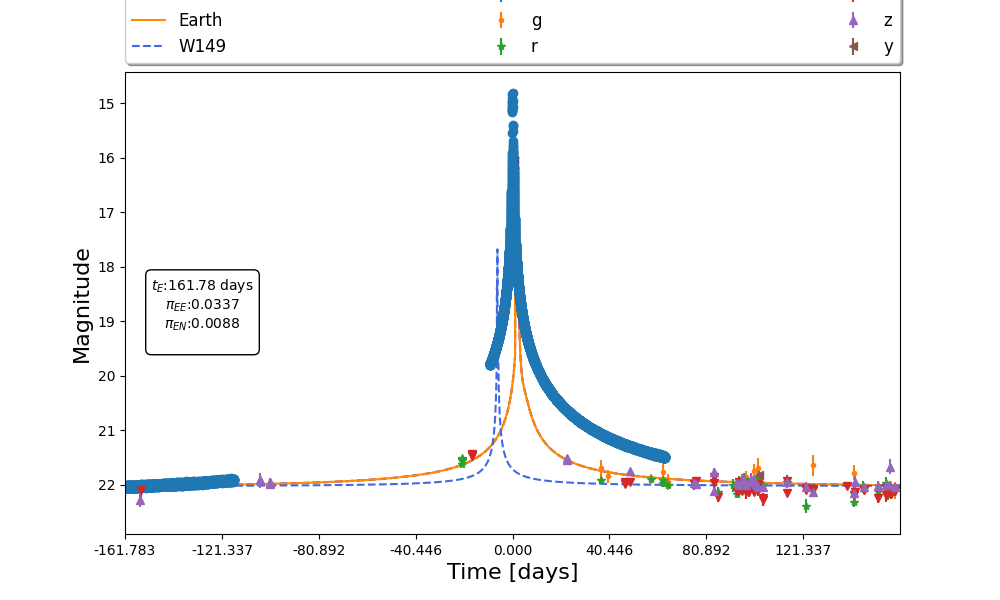

In [8]:
ssh = ssh_che()
#120
sources_array = [1000]
category = 'USBL'

# download_data(sources, category)
nset = 1
path_run = '/share/storage3/rubin/microlensing/romanrubin/RR2025/finalv2_set/Planets_systems/'
system_type = "Planets_systems"
path_save = os.getcwd()+f'/lightcurves/{system_type}_{nset}/'
if not os.path.exists(path_save):
    os.makedirs(path_save, exist_ok=True)
if not os.path.exists(path_save+f'Event_{sources_array[0]}.h5')==True:
    download_data(ssh,sources_array, nset, path_run, path_save)
else:
    print('The file already exist')


df_to_plot = create_df_to_plot(sources_array, category, path_save)
%matplotlib ipympl
# %matplotlib inline
plt.close('all')

fig, axes = graph_maker_1plot(df_to_plot, category, False)
# info, params, curves  = read_data(df_to_plot['path_event'].iloc[0])
# axes[0].axvspan(params['t_center']-1*params['tE']*np.sqrt(params['mass_ratio']),
#                 params['t_center']+1*params['tE']*np.sqrt(params['mass_ratio']),
#                 alpha=0.15,
#                 color='blue',label="t_{c}\pm t_{Ep}")

# axes[0].axvspan(params['t_center']-5*params['tE']*np.sqrt(params['rho']),params['t_center']+5*params['tE']*np.sqrt(params['rho']),alpha=0.25,color='red')
# plt.tight_layout()
plt.show()

In [ ]:
origin = originclass(params, info[2])
neworigin = origin.new_origin(params)
print(params['u_center'])
print(params['u_center'] - neworigin[0]*np.sin(params['alpha'])+neworigin[1]*np.cos(params['alpha']))
print(1/params['separation']-params['separation'])
